# Transformer from Scratch
**Tokenized Universe — Post 4**

Building every component of a modern Transformer LM from scratch, following CS336 Assignment 1 constraints:
- No `nn.Linear`, `nn.Embedding`, or `nn.MultiheadAttention`
- All weights initialized manually
- All operations implemented using raw PyTorch

Components covered:
1. `Linear` — weight matrix with Glorot init
2. `Embedding` — token lookup table
3. `RMSNorm` — root mean square layer normalization
4. `SwiGLUFFN` — gated feed-forward network
5. `softmax` — numerically stable softmax
6. `scaled_dot_product_attention` — the core attention operation
7. `RotaryPositionalEmbedding` — RoPE
8. `CausalMultiHeadSelfAttention` — full multi-head attention with causal mask
9. `TransformerBlock` — one layer with pre-norm + residual connections
10. `TransformerLM` — the full language model


In [1]:
# Standard imports
import math
import torch
import torch.nn as nn


## 1. Linear Layer

A weight matrix `W` of shape `(out, in)` initialized with Glorot (Xavier) uniform — sigma = sqrt(2 / (fan_in + fan_out)), truncated at ±3σ.

Forward: `y = x @ W.T` — implemented via `einsum` so it handles arbitrary batch dimensions cleanly.

In [2]:
class Linear(nn.Module):
    """
    A linear (fully-connected) layer without bias.

    Weight shape: (out_features, in_features) — same convention as nn.Linear.
    Initialized with Glorot (Xavier) normal, truncated at ±3σ.

    Args:
        in_features  (int): Size of each input sample.
        out_features (int): Size of each output sample.
        device: Target device (e.g. 'cuda', 'cpu').
        dtype:  Target dtype (e.g. torch.float32, torch.bfloat16).
    """

    def __init__(self, in_features, out_features, device=None, dtype=None):
        super().__init__()

        # Allocate the weight parameter (un-initialized)
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features, device=device, dtype=dtype)
        )

        # Glorot (Xavier) normal: sigma = sqrt(2 / (fan_in + fan_out))
        # Truncated at ±3σ to avoid extreme outliers at init
        sigma = math.sqrt(2.0 / (in_features + out_features))
        nn.init.trunc_normal_(self.weight, mean=0.0, std=sigma, a=-3 * sigma, b=3 * sigma)

    def forward(self, x):
        """
        Compute y = x @ W^T.

        Uses einsum so any number of leading batch dimensions work
        without explicit reshaping.

        Args:
            x: (..., in_features)
        Returns:
            y: (..., out_features)
        """
        # '... d_in, d_out d_in -> ... d_out'  reads as:
        #   for every position in batch (...), dot x's d_in with W's d_in,
        #   producing one scalar per d_out
        return torch.einsum("...i,oi->...o", x, self.weight)


## 2. Embedding Layer

A lookup table: shape `(vocab_size, d_model)`. Given integer token IDs, return the corresponding row vectors.

Initialized with truncated normal (mean=0, std=1).

In [3]:
class Embedding(nn.Module):
    """
    A simple token embedding lookup table.

    Stores a matrix of shape (num_embeddings, embedding_dim).
    Given a tensor of integer token IDs, returns the corresponding rows.

    Args:
        num_embeddings (int): Vocabulary size.
        embedding_dim  (int): Dimension of each embedding vector.
        device: Target device.
        dtype:  Target dtype.
    """

    def __init__(self, num_embeddings, embedding_dim, device=None, dtype=None):
        super().__init__()

        # The embedding table: one row per vocabulary token
        self.weight = nn.Parameter(
            torch.empty(num_embeddings, embedding_dim, device=device, dtype=dtype)
        )

        # Truncated normal init — keeps vectors near the unit sphere
        nn.init.trunc_normal_(self.weight, mean=0.0, std=1.0, a=-3.0, b=3.0)

    def forward(self, token_ids):
        """
        Look up embeddings for a batch of token IDs.

        Args:
            token_ids: Integer tensor of any shape (...)
        Returns:
            Embedding vectors of shape (..., embedding_dim)
        """
        # Direct index into the weight matrix — equivalent to one-hot @ weight
        return self.weight[token_ids]


## 3. RMSNorm

Root Mean Square Layer Normalization. Normalizes by the RMS of the activations (no mean centering), then scales by a learned vector `g`.

Computed in float32 for numerical stability, then cast back to the input dtype.

In [4]:
class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization (RMSNorm).

    Unlike LayerNorm, RMSNorm skips mean subtraction and normalizes
    only by the root-mean-square of the activations, then applies
    a learned per-dimension scale.

    Args:
        d_model (int):   Model dimension (last axis of input).
        eps     (float): Small constant for numerical stability.
        device: Target device.
        dtype:  Target dtype.
    """

    def __init__(self, d_model, eps=1e-5, device=None, dtype=None):
        super().__init__()
        self.eps = eps
        # Learned scale vector, initialized to ones (identity at init)
        self.weight = nn.Parameter(torch.ones(d_model, device=device, dtype=dtype))

    def forward(self, x):
        """
        Normalize x by its RMS and scale by the learned weight.

        Args:
            x: (..., d_model)
        Returns:
            Normalized tensor of same shape as x.
        """
        # Upcast to float32 to avoid precision loss during the norm computation
        in_dtype = x.dtype
        x = x.to(torch.float32)

        # RMS = sqrt( mean(x^2) + eps )
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)

        # Normalize then apply the learned scale
        result = (x / rms) * self.weight.to(torch.float32)

        # Cast back to original dtype (e.g. bfloat16 in mixed-precision training)
        return result.to(in_dtype)


## 4. SwiGLU Feed-Forward Network

SwiGLU = SiLU activation (sigmoid-weighted linear unit) + a gating mechanism.

Three projections: `W1` (gate input), `W3` (values), `W2` (output).
The hidden dim defaults to `ceil((8/3 * d_model) / 64) * 64` — parameter-equivalent to a 4× FFN but rounded up to the nearest multiple of 64 for GPU alignment.

In [5]:
class SwiGLUFFN(nn.Module):
    """
    SwiGLU Feed-Forward Network.

    SwiGLU combines a SiLU gate with an element-wise gating mechanism:
        output = W2( SiLU(W1(x)) * W3(x) )

    Three weight matrices:
      W1: projects x to the gate branch (gate_input)
      W3: projects x to the value branch (what to pass through)
      W2: projects the gated hidden state back to d_model

    The default hidden dimension is chosen to be parameter-equivalent
    to a standard 2-matrix FFN with d_ff = 4 * d_model, then rounded
    up to the nearest multiple of 64 for GPU memory alignment.

    Args:
        d_model (int): Model dimension.
        d_ff    (int): Hidden dimension. Auto-computed if None.
        device: Target device.
        dtype:  Target dtype.
    """

    def __init__(self, d_model, d_ff=None, device=None, dtype=None):
        super().__init__()

        if d_ff is None:
            # (8/3) * d_model is parameter-equivalent to 4*d_model with 3 matrices instead of 2
            # Round up to nearest multiple of 64 for efficient GPU tensor alignment
            d_ff = math.ceil(int(8 / 3 * d_model) / 64) * 64

        # Gate branch: produces the activation that controls information flow
        self.W1 = Linear(d_model, d_ff, device=device, dtype=dtype)

        # Output projection: maps gated hidden state back to d_model
        self.W2 = Linear(d_ff, d_model, device=device, dtype=dtype)

        # Value branch: produces the content that gets gated
        self.W3 = Linear(d_model, d_ff, device=device, dtype=dtype)

    def forward(self, x):
        """
        Apply SwiGLU transformation.

        Args:
            x: (..., d_model)
        Returns:
            Tensor of shape (..., d_model)
        """
        # Step 1: Compute gate — SiLU(W1(x)) = x * sigmoid(x)
        gate_input = self.W1(x)
        gate = gate_input * torch.sigmoid(gate_input)  # SiLU activation

        # Step 2: Compute values — what information the gate will filter
        values = self.W3(x)

        # Step 3: Element-wise gating, then project back to d_model
        return self.W2(gate * values)


## 5. Numerically Stable Softmax

Subtracts the row maximum before exponentiation to prevent `exp(large number)` overflow. Mathematically equivalent to standard softmax (the constant cancels in numerator and denominator).

In [6]:
def softmax(x, dim):
    """
    Numerically stable softmax along a given dimension.

    Subtracts the max value before exponentiating to avoid overflow
    from large attention scores. The shift cancels out mathematically:
        softmax(x) == softmax(x - max(x))

    Args:
        x   (Tensor): Input tensor.
        dim (int):    Dimension along which to apply softmax.

    Returns:
        Tensor of same shape as x, values sum to 1 along `dim`.
    """
    # Subtract max for numerical stability (prevents exp() overflow)
    x_shifted = x - x.max(dim=dim, keepdim=True).values

    # Standard softmax: exp(x) / sum(exp(x))
    exp_x = torch.exp(x_shifted)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)


## 6. Scaled Dot-Product Attention

The core attention operation:
1. Compute raw scores: `Q @ K^T / sqrt(d_k)`
2. Apply causal mask (set future positions to -inf)
3. Softmax over the key dimension
4. Weighted sum of values: `attn_weights @ V`

In [7]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Scaled dot-product attention.

    Computes:
        Attention(Q, K, V) = softmax( QK^T / sqrt(d_k) ) * V

    Args:
        query: (..., n, d_k)  — query vectors
        key:   (..., m, d_k)  — key vectors
        value: (..., m, d_v)  — value vectors
        mask:  (..., n, m) boolean tensor, True = attend, False = mask out

    Returns:
        Output tensor of shape (..., n, d_v)
    """
    # d_k is the key/query dimension — used for scaling
    d_k = query.shape[-1]

    # Step 1: Compute raw attention scores — QK^T
    # '... n d_k, ... m d_k -> ... n m' = for each query position n,
    # compute dot product with every key position m
    scores = torch.einsum("...nd,...md->...nm", query, key)

    # Step 2: Scale by 1/sqrt(d_k) to prevent softmax saturation
    scores = scores / math.sqrt(d_k)

    # Step 3: Apply mask — positions where mask is False get -inf,
    # so after softmax they become 0 (no attention)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))

    # Step 4: Softmax over key dimension → attention weights
    attn_weights = softmax(scores, dim=-1)

    # Step 5: Weighted sum over value vectors
    # '... n m, ... m d_v -> ... n d_v'
    return torch.einsum("...nm,...mv->...nv", attn_weights, value)


## 7. Rotary Positional Embedding (RoPE)

Instead of adding positional encodings, RoPE *rotates* query and key vectors by an angle proportional to their position. This encodes relative distances directly in the dot product — closer tokens produce higher scores naturally.

Applied only to Q and K, not V — position tells you *where to look*, not *what to say*.

In [8]:
class RotaryPositionalEmbedding(nn.Module):
    """
    Rotary Positional Embedding (RoPE).

    Rotates query/key vectors in 2D sub-spaces using position-dependent angles.
    The rotation angle for dimension pair (2i, 2i+1) at position p is:
        theta_i = p / (base ** (2i / d_k))

    Precomputed cos/sin tables are stored as non-persistent buffers
    (not saved in model checkpoints, recomputed on load).

    RoPE is applied to Q and K only — NOT to V.
    Position encodes where to look, not what to say.

    Args:
        theta       (float): Base frequency (10000 in original RoPE, 500000 in LLaMA 3).
        d_k         (int):   Head dimension (must be even).
        max_seq_len (int):   Maximum sequence length to precompute.
        device:              Target device.
    """

    def __init__(self, theta, d_k, max_seq_len, device=None):
        super().__init__()
        assert d_k % 2 == 0, "Head dimension d_k must be even for RoPE"

        # --- Precompute inverse frequencies ---
        # k = [0, 1, 2, ..., d_k/2 - 1]
        k = torch.arange(0, d_k // 2, dtype=torch.float32, device=device)

        # inv_freq[i] = 1 / theta^(2i / d_k)
        # Lower dimensions rotate fast (high frequency), higher dimensions rotate slow
        inv_freq = 1.0 / (theta ** (2 * k / d_k))

        # --- Precompute angles for all positions ---
        # positions = [0, 1, 2, ..., max_seq_len - 1]
        positions = torch.arange(max_seq_len, dtype=torch.float32, device=device)

        # angles[p, i] = p * inv_freq[i]  — shape: (max_seq_len, d_k/2)
        angles = torch.outer(positions, inv_freq)

        # Duplicate angles so each pair (i, i + d_k/2) gets the same angle
        # Final shape: (max_seq_len, d_k)
        angles = torch.cat([angles, angles], dim=-1)

        # Cache cos and sin tables — not model parameters, not saved in checkpoints
        self.register_buffer("cos_cache", angles.cos(), persistent=False)
        self.register_buffer("sin_cache", angles.sin(), persistent=False)

    def _rotate_half(self, x):
        """
        Rearrange x to represent the perpendicular rotation component.

        For a 2D vector [a, b], the perpendicular (90° rotation) is [-b, a].
        For a d_k-dimensional vector split into two halves [x1, x2]:
            rotate_half([x1, x2]) = [-x2, x1]

        Args:
            x: (..., d_k)
        Returns:
            Tensor of same shape: [-x[d_k/2:], x[:d_k/2]]
        """
        half = x.shape[-1] // 2
        # Second half (negated) goes first, then first half
        return torch.cat([-x[..., half:], x[..., :half]], dim=-1)

    def forward(self, x, token_positions):
        """
        Apply RoPE rotation to x at the given token positions.

        x_rotated = x * cos(θ) + rotate_half(x) * sin(θ)

        This is the discrete analog of rotating a 2D vector:
            [a, b] → [a*cos - b*sin, a*sin + b*cos]

        Args:
            x:               (..., seq_len, d_k) — query or key tensor
            token_positions: (seq_len,) — integer positions to look up

        Returns:
            Rotated tensor of same shape as x.
        """
        # Look up precomputed cos and sin for each position
        cos = self.cos_cache[token_positions]  # (seq_len, d_k)
        sin = self.sin_cache[token_positions]  # (seq_len, d_k)

        # Apply rotation: x * cos + perpendicular(x) * sin
        return x * cos + self._rotate_half(x) * sin


## 8. Causal Multi-Head Self-Attention

Projects input into Q, K, V with learned weight matrices, splits into multiple heads, applies RoPE to Q and K, runs scaled dot-product attention with a causal (lower-triangular) mask, then merges heads and projects output.

In [9]:
class CausalMultiHeadSelfAttention(nn.Module):
    """
    Causal Multi-Head Self-Attention with Rotary Positional Embeddings.

    Each token attends to all previous tokens (including itself) but NOT
    to future tokens — enforced via a lower-triangular boolean mask.

    Heads run in parallel: d_model is split evenly across num_heads,
    each head has dimension d_k = d_model // num_heads.

    RoPE is applied to Q and K after splitting into heads.
    V is NOT rotated — position encodes where to look, not what to say.

    Args:
        d_model     (int):   Total model dimension.
        num_heads   (int):   Number of attention heads.
        max_seq_len (int):   Maximum sequence length (for RoPE precomputation).
        theta       (float): RoPE base frequency.
        device:              Target device.
        dtype:               Target dtype.
    """

    def __init__(self, d_model, num_heads, max_seq_len, theta=10000.0, device=None, dtype=None):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head

        # Four projection matrices: Q, K, V, and output
        # All project from/to d_model (heads are carved out after projection)
        self.W_Q = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_K = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_V = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_O = Linear(d_model, d_model, device=device, dtype=dtype)

        # RoPE module — precomputes cos/sin tables up to max_seq_len
        self.rope = RotaryPositionalEmbedding(
            theta=theta, d_k=self.d_k, max_seq_len=max_seq_len, device=device
        )

    def forward(self, x):
        """
        Run causal multi-head self-attention.

        Args:
            x: (batch_size, seq_len, d_model)

        Returns:
            Output tensor of shape (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # --- Step 1: Project input to Q, K, V ---
        # Each is shape: (batch_size, seq_len, d_model)
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # --- Step 2: Split into heads ---
        # Reshape: (batch, seq, d_model) -> (batch, num_heads, seq, d_k)
        # Transpose puts heads before seq so attention runs per-head
        def split_heads(t):
            """Reshape (batch, seq, d_model) -> (batch, num_heads, seq, d_k)"""
            t = t.view(batch_size, seq_len, self.num_heads, self.d_k)
            return t.transpose(1, 2)  # -> (batch, num_heads, seq, d_k)

        Q = split_heads(Q)  # (batch, heads, seq, d_k)
        K = split_heads(K)  # (batch, heads, seq, d_k)
        V = split_heads(V)  # (batch, heads, seq, d_k)

        # --- Step 3: Apply RoPE to Q and K only ---
        # positions = [0, 1, 2, ..., seq_len - 1]
        positions = torch.arange(seq_len, device=x.device)
        Q = self.rope(Q, positions)  # Rotate queries
        K = self.rope(K, positions)  # Rotate keys
        # V is NOT rotated — values represent content, not position

        # --- Step 4: Build causal mask ---
        # Lower-triangular boolean matrix: True = allowed to attend
        # Position i can attend to positions 0..i (including itself)
        causal_mask = torch.tril(
            torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device)
        )

        # --- Step 5: Scaled dot-product attention (parallel across all heads) ---
        # attn_out: (batch, num_heads, seq, d_k)
        attn_out = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

        # --- Step 6: Merge heads back ---
        # (batch, heads, seq, d_k) -> (batch, seq, heads, d_k) -> (batch, seq, d_model)
        attn_out = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out.view(batch_size, seq_len, self.d_model)

        # --- Step 7: Output projection ---
        return self.W_O(attn_out)


## 9. Transformer Block

One full block: **pre-norm attention** + residual, then **pre-norm FFN** + residual.

Pre-norm means the normalization happens *before* each sub-layer, not after. This is the modern convention (GPT-2 onward) — it makes training more stable because the residual stream stays un-normalized and easy to route gradients through.

In [10]:
class TransformerBlock(nn.Module):
    """
    A single Transformer block with pre-norm and residual connections.

    Architecture (pre-norm style):
        x = x + Attention( RMSNorm(x) )
        x = x + FFN( RMSNorm(x) )

    The residual stream x flows unchanged through both additions,
    giving gradients a direct highway back to early layers.

    Args:
        d_model     (int):   Model dimension.
        num_heads   (int):   Number of attention heads.
        d_ff        (int):   FFN hidden dimension.
        max_seq_len (int):   Max sequence length (for RoPE).
        theta       (float): RoPE base frequency.
        device:              Target device.
        dtype:               Target dtype.
    """

    def __init__(self, d_model, num_heads, d_ff, max_seq_len, theta=10000.0, device=None, dtype=None):
        super().__init__()

        # Pre-norm before attention
        self.norm1 = RMSNorm(d_model, device=device, dtype=dtype)

        # Causal multi-head self-attention with RoPE
        self.attn = CausalMultiHeadSelfAttention(
            d_model, num_heads, max_seq_len, theta, device, dtype
        )

        # Pre-norm before feed-forward
        self.norm2 = RMSNorm(d_model, device=device, dtype=dtype)

        # SwiGLU feed-forward network
        self.ffn = SwiGLUFFN(d_model=d_model, d_ff=d_ff, device=device, dtype=dtype)

    def forward(self, x):
        """
        Forward pass through one Transformer block.

        Args:
            x: (batch_size, seq_len, d_model)

        Returns:
            Tensor of same shape as x.
        """
        # Attention sub-layer with pre-norm and residual
        # norm1 normalizes x, attention refines it, residual adds it back
        x = x + self.attn(self.norm1(x))

        # FFN sub-layer with pre-norm and residual
        x = x + self.ffn(self.norm2(x))

        return x


## 10. Full Transformer Language Model

Stack N Transformer blocks after a token embedding layer. Apply a final RMSNorm, then a linear head that projects to vocabulary logits.

The output is **unnormalized logits** — apply `softmax` or `log_softmax` outside this module.

In [11]:
class TransformerLM(nn.Module):
    """
    Full Transformer Language Model.

    Architecture:
        token_ids
          -> Embedding lookup
          -> N x TransformerBlock
          -> RMSNorm
          -> Linear (lm_head) -> logits over vocab

    Returns unnormalized logits. Apply cross-entropy loss externally
    (PyTorch's nn.CrossEntropyLoss accepts logits directly).

    Args:
        vocab_size      (int):   Number of tokens in the vocabulary.
        context_length  (int):   Maximum sequence length.
        d_model         (int):   Model dimension.
        num_layers      (int):   Number of Transformer blocks.
        num_heads       (int):   Number of attention heads per block.
        d_ff            (int):   FFN hidden dimension. Auto-computed if None.
        theta           (float): RoPE base frequency.
        device:                  Target device.
        dtype:                   Target dtype.
    """

    def __init__(
        self,
        vocab_size,
        context_length,
        d_model,
        num_layers,
        num_heads,
        d_ff=None,
        theta=10000.0,
        device=None,
        dtype=None,
    ):
        super().__init__()

        if d_ff is None:
            # Default: parameter-equivalent to 4x FFN, rounded to nearest 64
            d_ff = math.ceil(int(8 / 3 * d_model) / 64) * 64

        # Token embedding table: vocab_size rows, d_model columns
        self.token_embedding = Embedding(vocab_size, d_model, device=device, dtype=dtype)

        # Stack of N identical Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, context_length, theta, device, dtype)
            for _ in range(num_layers)
        ])

        # Final normalization before the output projection
        self.final_norm = RMSNorm(d_model, device=device, dtype=dtype)

        # Output (language model) head: d_model -> vocab_size
        # Produces one logit per vocabulary token per position
        self.lm_head = Linear(d_model, vocab_size, device=device, dtype=dtype)

    def forward(self, token_ids):
        """
        Forward pass through the full Transformer LM.

        Args:
            token_ids: (batch_size, seq_len) integer tensor of token IDs

        Returns:
            logits: (batch_size, seq_len, vocab_size) — unnormalized log-probabilities
        """
        # Convert token IDs to dense vectors
        x = self.token_embedding(token_ids)  # (batch, seq, d_model)

        # Pass through every Transformer block sequentially
        for block in self.blocks:
            x = block(x)  # (batch, seq, d_model) — shape unchanged

        # Normalize the final hidden states
        x = self.final_norm(x)

        # Project to vocabulary logits
        return self.lm_head(x)  # (batch, seq, vocab_size)


## 11. Sanity Check — GPT-2 Small Config

Instantiate a GPT-2 small equivalent and run a forward pass on random token IDs.
Expected output shape: `(2, 128, 50257)`.

In [12]:
# GPT-2 Small configuration
VOCAB_SIZE = 50257      # GPT-2 vocabulary size
CONTEXT_LENGTH = 1024   # Maximum sequence length
D_MODEL = 768           # Model dimension
NUM_LAYERS = 12         # Number of Transformer blocks
NUM_HEADS = 12          # Number of attention heads
THETA = 10000.0         # RoPE base frequency

# Instantiate the model
model = TransformerLM(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    theta=THETA,
)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"  (~{total_params / 1e6:.1f}M — GPT-2 Small is ~117M)")

# --- Forward pass sanity check ---
# Random token IDs: batch of 2 sequences, each 128 tokens long
batch_size = 2
seq_len = 128
token_ids = torch.randint(0, VOCAB_SIZE, (batch_size, seq_len))

# Run forward pass
with torch.no_grad():
    logits = model(token_ids)

# Expected: (2, 128, 50257)
print(f"\nInput shape:  {tuple(token_ids.shape)}")
print(f"Output shape: {tuple(logits.shape)}")
assert logits.shape == (batch_size, seq_len, VOCAB_SIZE), "Shape mismatch!"
print("\nAll good! Shape check passed.")


Total parameters: 162,148,608
  (~162.1M — GPT-2 Small is ~117M)

Input shape:  (2, 128)
Output shape: (2, 128, 50257)

All good! Shape check passed.


# Part 2: Training on TinyStories

Now we train the model we built in Part 1.

**What this section covers:**
1. BPE Tokenizer — load your CS336 vocab/merges files
2. Loss functions — log-softmax and cross-entropy
3. AdamW optimizer — from scratch
4. Learning rate schedule — cosine annealing with warmup
5. Gradient clipping
6. Data loading — memory-mapped numpy
7. Checkpointing — save and resume
8. Training loop
9. Text generation — temperature + top-p sampling
10. Full training run on TinyStories

**Files needed:**
- `tinystories_train.txt` — raw training text
- `tinystories_bpe.vocab` — BPE vocabulary (from CS336 BPE training)
- `tinystories_bpe.merges` — BPE merges (from CS336 BPE training)


## 12. Setup & Imports

In [13]:
import os
import time
import re
import json
import math
import pickle
import numpy as np
from dataclasses import dataclass
from typing import Iterator
import torch
import torch.nn as nn

# Detect best available device
device = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


In [14]:
# Install Weights & Biases for experiment tracking
# W&B logs train/val loss, perplexity, lr, grad norm vs steps and wall-clock time
!pip install -q wandb
import wandb
print(f'wandb {wandb.__version__} ready')

# Login once — creates ~/.netrc so subsequent runs don't need interaction
# wandb.login()   # ← uncomment and run this the first time


wandb 0.27.1 ready


## 13. Upload Your Files (Colab)

## 14. BPE Tokenizer

Loads your CS336 vocab and merges files and implements BPE encoding/decoding.
Handles the common CS336 serialization formats automatically.


In [15]:
class BPETokenizer:
    """
    Byte-Pair Encoding tokenizer.

    Loads a pre-trained BPE vocabulary and merge list produced by
    CS336 Assignment 1 BPE training.

    CS336 serialization format (tab-separated hex text):
        vocab:  id<TAB>hex_bytes     e.g. "256\t6865"  -> token 256 = b'he'
        merges: hex_a<TAB>hex_b      e.g. "68\t65"     -> merge b'h' + b'e'

    Also handles pickle and JSON for compatibility.

    Args:
        vocab:          dict[int, bytes] — token ID to byte string
        merges:         list[tuple[bytes, bytes]] — merge rules in order
        special_tokens: list[str] — tokens like '<|endoftext|>'
    """

    # GPT-2 pre-tokenization pattern
    GPT2_PAT = re.compile(
        r"""'(?:[sdmt]|ll|ve|re)|[^\r\n\w]?\w+|\d{1,3}| ?[^\s\w]+[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+"""
    )

    def __init__(self, vocab, merges, special_tokens=None):
        self.vocab         = vocab
        self.merges        = merges
        self.token_to_id   = {v: k for k, v in vocab.items()}
        self.merge_ranks   = {pair: i for i, pair in enumerate(merges)}
        self.special_tokens = special_tokens or []

        # Register special tokens in vocab if not already present
        next_id = max(self.vocab.keys()) + 1 if self.vocab else 0
        for st in self.special_tokens:
            st_bytes = st.encode('utf-8')
            if st_bytes not in self.token_to_id:
                self.vocab[next_id]        = st_bytes
                self.token_to_id[st_bytes] = next_id
                next_id += 1

    # ── File loading ────────────────────────────────────────────────────

    @classmethod
    def from_files(cls, vocab_path, merges_path, special_tokens=None):
        """
        Load tokenizer from CS336 vocab and merges files.

        Args:
            vocab_path:     Path to .vocab file.
            merges_path:    Path to .merges file.
            special_tokens: List of special token strings.

        Returns:
            BPETokenizer instance.
        """
        vocab  = cls._load_vocab(vocab_path)
        merges = cls._load_merges(merges_path)
        return cls(vocab, merges, special_tokens)

    @staticmethod
    def _load_vocab(path):
        """
        Load vocab file.

        Priority order:
          1. CS336 tab-separated hex:  id<TAB>hex_bytes  (e.g. "0\t00")
          2. Pickle: dict[int, bytes]
          3. JSON:   {"id": [byte_ints]} or {"id": "hex_string"}
        """
        # 1. CS336 tab-separated hex (primary format)
        try:
            vocab = {}
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.rstrip('\n')
                    if '\t' not in line:
                        continue
                    idx_str, hex_str = line.split('\t', 1)
                    vocab[int(idx_str)] = bytes.fromhex(hex_str)
            if vocab:
                return vocab
        except Exception:
            pass

        # 2. Pickle
        try:
            with open(path, 'rb') as f:
                data = pickle.load(f)
            if isinstance(data, dict):
                return {int(k): (v if isinstance(v, bytes) else bytes(v))
                        for k, v in data.items()}
        except Exception:
            pass

        # 3. JSON
        try:
            with open(path, 'r', encoding='utf-8') as f:
                raw = json.load(f)
            vocab = {}
            for k, v in raw.items():
                if isinstance(v, list):
                    vocab[int(k)] = bytes(v)
                elif isinstance(v, str):
                    try:
                        vocab[int(k)] = bytes.fromhex(v)
                    except ValueError:
                        vocab[int(k)] = v.encode('latin-1')
            return vocab
        except Exception:
            pass

        raise ValueError(f'Could not parse vocab file: {path}')

    @staticmethod
    def _load_merges(path):
        """
        Load merges file.

        Priority order:
          1. CS336 tab-separated hex:  hex_a<TAB>hex_b  (e.g. "68\t65")
          2. Pickle: list[tuple[bytes, bytes]]
          3. JSON:   list of [hex_a, hex_b] pairs
        """
        # 1. CS336 tab-separated hex (primary format)
        try:
            merges = []
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'):
                        continue
                    if '\t' not in line:
                        continue
                    a_hex, b_hex = line.split('\t', 1)
                    merges.append((bytes.fromhex(a_hex), bytes.fromhex(b_hex)))
            if merges:
                return merges
        except Exception:
            pass

        # 2. Pickle
        try:
            with open(path, 'rb') as f:
                data = pickle.load(f)
            if isinstance(data, list):
                return [(a if isinstance(a, bytes) else bytes(a),
                         b if isinstance(b, bytes) else bytes(b))
                        for a, b in data]
        except Exception:
            pass

        # 3. JSON
        try:
            with open(path, 'r', encoding='utf-8') as f:
                raw = json.load(f)
            merges = []
            for pair in raw:
                a, b = pair
                a = bytes(a) if isinstance(a, list) else bytes.fromhex(a)
                b = bytes(b) if isinstance(b, list) else bytes.fromhex(b)
                merges.append((a, b))
            return merges
        except Exception:
            pass

        raise ValueError(f'Could not parse merges file: {path}')

    # ── Encoding ────────────────────────────────────────────────────────

    def encode(self, text):
        """
        Encode a string into a list of token IDs.

        Special tokens are matched first and passed through as single
        tokens; the remaining text is BPE-encoded.

        Args:
            text: Input string.

        Returns:
            List of integer token IDs.
        """
        if self.special_tokens:
            pattern = '(' + '|'.join(re.escape(st) for st in self.special_tokens) + ')'
            parts = re.split(pattern, text)
        else:
            parts = [text]

        ids = []
        for part in parts:
            if part in self.special_tokens:
                ids.append(self.token_to_id[part.encode('utf-8')])
            elif part:
                ids.extend(self._encode_chunk(part))
        return ids

    def _encode_chunk(self, text):
        """Encode a chunk of text (no special tokens) into token IDs."""
        ids = []
        for word in self.GPT2_PAT.findall(text):
            word_bytes = tuple(bytes([b]) for b in word.encode('utf-8'))
            for token in self._apply_merges(word_bytes):
                if token in self.token_to_id:
                    ids.append(self.token_to_id[token])
        return ids

    def _apply_merges(self, token_seq):
        """
        Apply BPE merges greedily to a sequence of byte tokens.

        At each step, find the highest-priority merge (lowest rank)
        among all adjacent pairs and apply it. Repeat until no
        more merges apply.

        Args:
            token_seq: tuple of bytes objects, one per byte initially.

        Returns:
            tuple of bytes objects after all applicable merges.
        """
        tokens = list(token_seq)
        while len(tokens) > 1:
            best_rank = float('inf')
            best_idx  = -1
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                rank = self.merge_ranks.get(pair, float('inf'))
                if rank < best_rank:
                    best_rank = rank
                    best_idx  = i
            if best_idx == -1:
                break
            merged = tokens[best_idx] + tokens[best_idx + 1]
            tokens = tokens[:best_idx] + [merged] + tokens[best_idx + 2:]
        return tuple(tokens)

    # ── Decoding ────────────────────────────────────────────────────────

    def decode(self, ids):
        """
        Decode a list of token IDs back to a string.

        Args:
            ids: List of integer token IDs.

        Returns:
            Decoded string.
        """
        byte_string = b''.join(self.vocab[i] for i in ids if i in self.vocab)
        return byte_string.decode('utf-8', errors='replace')

    @property
    def vocab_size(self):
        return len(self.vocab)

    @property
    def eot_token(self):
        """Token ID for <|endoftext|>."""
        eot_bytes = '<|endoftext|>'.encode('utf-8')
        return self.token_to_id.get(eot_bytes, 0)


### Load and test the tokenizer

In [16]:
# # ── Load your CS336 BPE tokenizer ────────────────────────────────────────
# VOCAB_PATH  = '/content/tinystories_bpe.vocab'
# MERGES_PATH = '/content/tinystories_bpe.merges'

# tokenizer = BPETokenizer.from_files(
#     vocab_path     = VOCAB_PATH,
#     merges_path    = MERGES_PATH,
#     special_tokens = ['<|endoftext|>'],
# )

# print(f'Vocabulary size: {tokenizer.vocab_size:,}')
# print(f'Number of merges: {len(tokenizer.merges):,}')
# print(f'EOT token ID: {tokenizer.eot_token}')

# # Sanity check
# test = 'Once upon a time, there was a little girl named Lily.'
# ids  = tokenizer.encode(test)
# back = tokenizer.decode(ids)
# print(f'\nTest encode/decode:')
# print(f'  Input:   {test}')
# print(f'  Tokens:  {ids}')
# print(f'  Decoded: {back}')
# print(f'  Match: {test == back}')


## 15. Loss Functions

Cross-entropy loss for next-token prediction. Uses log-softmax directly
rather than `log(softmax(x))` to avoid numerical underflow.


In [17]:
def log_softmax(x: torch.Tensor, dim: int) -> torch.Tensor:
    """
    Numerically stable log-softmax.

    Computing log(softmax(x)) naively risks underflow: softmax can
    produce 0.0 for low-probability tokens, and log(0) = -inf.
    Working in log space avoids the intermediate softmax entirely.

    Args:
        x:   Input tensor.
        dim: Dimension to apply log-softmax along.

    Returns:
        Log probabilities, same shape as x.
    """
    x_stable    = x - x.max(dim=dim, keepdim=True).values
    log_sum_exp = torch.log(torch.exp(x_stable).sum(dim=dim, keepdim=True))
    return x_stable - log_sum_exp


def cross_entropy_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Cross-entropy loss for next-token prediction.

    For each position, picks the log probability of the correct
    next token and negates it. Averaged over all positions.

    exp(loss) gives perplexity — the effective vocabulary size
    the model is 'choosing from' at each step.

    Args:
        logits:  (batch_size, seq_len, vocab_size) — raw model output.
        targets: (batch_size, seq_len) — correct next token IDs.

    Returns:
        Scalar mean cross-entropy loss.
    """
    log_probs      = log_softmax(logits, dim=-1)
    log_probs_flat = log_probs.view(-1, logits.size(-1))
    targets_flat   = targets.view(-1)
    batch_idx      = torch.arange(log_probs_flat.size(0), device=logits.device)
    target_log_probs = log_probs_flat[batch_idx, targets_flat]
    return -target_log_probs.mean()


## 16. AdamW Optimizer

Adam with decoupled weight decay. Tracks two moment estimates per
parameter: `m` (smoothed gradient direction) and `v` (smoothed squared
gradient magnitude). Weight decay is applied directly to parameters
after the Adam step — not folded into the gradient — so it is not
distorted by the adaptive scaling.


In [18]:
class AdamW(torch.optim.Optimizer):
    """
    AdamW optimizer — Adam with decoupled weight decay.

    Per-parameter adaptive learning rates via two moment estimates:
      m: exponential moving average of gradients    (direction)
      v: exponential moving average of grad squares (curvature)

    Update rule:
      m_t = beta1 * m_{t-1} + (1 - beta1) * g
      v_t = beta2 * v_{t-1} + (1 - beta2) * g^2
      m_hat = m_t / (1 - beta1^t)     <- bias correction
      v_hat = v_t / (1 - beta2^t)     <- bias correction
      theta -= lr * m_hat / (sqrt(v_hat) + eps)   <- Adam step
      theta -= lr * weight_decay * theta           <- weight decay

    Args:
        params:       Model parameters.
        lr:           Peak learning rate.
        betas:        (beta1, beta2) moment decay rates.
        eps:          Numerical stability constant.
        weight_decay: L2 regularization (decoupled from Adam step).
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999),
                 eps=1e-8, weight_decay=0.01):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None

        for group in self.param_groups:
            lr           = group['lr']
            beta1, beta2 = group['betas']
            eps          = group['eps']
            wd           = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                g = p.grad
                state = self.state[p]

                # Initialise state on first step
                if len(state) == 0:
                    state['step'] = 0
                    state['m']    = torch.zeros_like(p)
                    state['v']    = torch.zeros_like(p)

                state['step'] += 1
                t = state['step']
                m, v = state['m'], state['v']

                # Update moment estimates
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)

                # Bias-corrected estimates
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                # Adam step
                p.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)

                # Decoupled weight decay (applied directly, not through gradient)
                p.mul_(1 - lr * wd)

        return loss


## 17. Learning Rate Schedule

Cosine annealing with linear warmup — the schedule used to train LLaMA (CS336 Section 4.3).

Three phases: linear warmup → cosine decay → flat minimum.


In [19]:
def get_lr_cosine_schedule(
    t: int,
    alpha_max: float,
    alpha_min: float,
    T_w: int,
    T_c: int,
) -> float:
    """
    Cosine annealing learning rate schedule (LLaMA / CS336 variant).

    Phase 1 — Warmup  [0, T_w):      lr = (t / T_w) * alpha_max
    Phase 2 — Cosine  [T_w, T_c]:    lr = alpha_min + 0.5*(1+cos(progress*pi))
                                              * (alpha_max - alpha_min)
    Phase 3 — Flat    (T_c, inf):    lr = alpha_min

    Args:
        t:         Current iteration (0-indexed).
        alpha_max: Peak learning rate (end of warmup).
        alpha_min: Minimum learning rate (floor after T_c).
        T_w:       Warmup iterations.
        T_c:       End of cosine annealing.

    Returns:
        Learning rate scalar for step t.
    """
    if t < T_w:
        return (t / T_w) * alpha_max
    if t > T_c:
        return alpha_min
    progress     = (t - T_w) / (T_c - T_w)
    cosine_decay = 0.5 * (1.0 + math.cos(progress * math.pi))
    return alpha_min + cosine_decay * (alpha_max - alpha_min)


## 18. Gradient Clipping

Clips the global gradient norm before each optimizer step.
Prevents a single outlier batch from derailing training.


In [20]:
def clip_gradient_norm(
    parameters,
    max_norm: float,
    eps: float = 1e-6,
) -> float:
    """
    Clip gradients by global L2 norm.

    If the global norm exceeds max_norm, scales ALL gradients down
    uniformly so the global norm equals max_norm exactly.
    Preserves the direction of the gradient update.

    Args:
        parameters: Iterable of tensors with .grad attributes.
        max_norm:   Maximum allowed global gradient norm.
        eps:        Stability constant for near-zero norms.

    Returns:
        Global gradient norm before clipping (log this!).
    """
    grads = [p.grad for p in parameters if p.grad is not None]
    if not grads:
        return 0.0
    total_norm = torch.sqrt(sum(g.pow(2).sum() for g in grads) + eps)
    if total_norm > max_norm:
        scale = max_norm / total_norm
        for g in grads:
            g.mul_(scale)
    return total_norm.item()


## 19. Data Loading

Samples random windows from a flat token array. Uses `np.memmap` to avoid
loading the full dataset into RAM — only the accessed pages are fetched from disk.


In [21]:
def get_batch(
    dataset: np.ndarray,
    batch_size: int,
    context_length: int,
    device: str,
) -> tuple:
    """
    Sample a random batch of (input, target) token sequences.

    inputs[i, t]  = token at position t
    targets[i, t] = token at position t+1 (the correct next token)

    Every token is simultaneously an input and a training target.

    Args:
        dataset:        1D numpy array of token IDs (use np.memmap for large files).
        batch_size:     Number of sequences per batch.
        context_length: Tokens per sequence.
        device:         PyTorch device string.

    Returns:
        (inputs, targets) both of shape (batch_size, context_length).
    """
    max_start = len(dataset) - context_length - 1
    starts    = np.random.randint(0, max_start, size=(batch_size,))
    inputs    = np.stack([dataset[s     : s + context_length    ] for s in starts])
    targets   = np.stack([dataset[s + 1 : s + context_length + 1] for s in starts])
    return (
        torch.tensor(inputs,  dtype=torch.long).to(device),
        torch.tensor(targets, dtype=torch.long).to(device),
    )


## 20. Checkpointing

Saves model weights, optimizer state (moment estimates), and iteration number.
All three are needed to resume training exactly where it left off.


In [22]:
def save_checkpoint(model, optimizer, iteration, out):
    """
    Save training checkpoint to disk.

    Args:
        model:     TransformerLM.
        optimizer: AdamW optimizer.
        iteration: Current step number (for resuming lr schedule).
        out:       File path or file-like object.
    """
    torch.save({
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'iteration': iteration,
    }, out)


def load_checkpoint(src, model, optimizer):
    """
    Load checkpoint and restore model and optimizer state.

    Args:
        src:       File path or file-like object.
        model:     TransformerLM to restore weights into.
        optimizer: AdamW to restore moment estimates into.

    Returns:
        Iteration number saved in checkpoint.
    """
    ckpt = torch.load(src, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    return ckpt['iteration']


## 21. TinyStories Training Configuration

Follows CS336 Assignment 1 Section 7.2 hyperparameters.
Target: ~17M parameters, validation loss ≤ 1.45 (≤ 2.00 for low-resource/CPU).


In [23]:
@dataclass
class TinyStoriesConfig:
    """
    Model + training hyperparameters for TinyStories (CS336 Section 7.2).

    Model is ~17M parameters with the settings below.
    Tune alpha_max first — it has the biggest impact on final loss.
    """
    # ── Model ──────────────────────────────────────────────────────────
    vocab_size:      int   = 10000   # CS336 BPE vocab size
    context_length:  int   = 256
    d_model:         int   = 512
    num_layers:      int   = 4
    num_heads:       int   = 16   # CS336 Section 7.2 spec
    d_ff:            int   = 1344    # ceil((8/3 * 512) / 64) * 64
    theta:           float = 10000.0

    # ── Ablation flags (set by experiment cells below) ─────────────────────
    norm_type:       str   = 'pre'    # 'pre' | 'post' | 'none'
    use_rope:        bool  = True
    ffn_type:        str   = 'swiglu'  # 'swiglu' | 'silu'

    # ── Optimizer ──────────────────────────────────────────────────────
    alpha_max:       float = 1e-3    # ← tune this first
    alpha_min:       float = 1e-4
    beta1:           float = 0.9
    beta2:           float = 0.999
    eps:             float = 1e-8
    weight_decay:    float = 0.1
    max_grad_norm:   float = 1.0

    # ── Schedule ───────────────────────────────────────────────────────
    num_steps:       int   = 5000    # increase for better results
    warmup_steps:    int   = 200

    # ── Training ───────────────────────────────────────────────────────
    batch_size:      int   = 32      # reduce to 8 if OOM on Colab free tier

    # ── Logging & checkpointing ────────────────────────────────────────
    log_every:       int   = 50
    val_every:       int   = 500
    val_steps:       int   = 20
    save_every:      int   = 1000
    out_dir:         str   = 'checkpoints'
    resume:          str   = None    # path to checkpoint, or None


    # ── Weights & Biases ───────────────────────────────────────────────
    use_wandb:       bool  = True             # set False to disable W&B
    wandb_project:   str   = 'tokenized-universe-batch_size'
    wandb_run_name:  str   = 'bs_32'             # auto-generated if None

cfg = TinyStoriesConfig()

# Override vocab_size to match your tokenizer
cfg.vocab_size = tokenizer.vocab_size
print(f'Config: {cfg}')

# Verify parameter count
_m = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff,
)
total = sum(p.numel() for p in _m.parameters())
print(f'Parameters: {total:,} ({total/1e6:.1f}M)')
del _m


## 22. Training Loop

One step: sample batch → forward → loss → backward → clip → schedule → optimizer step → zero grads.


In [24]:
@torch.no_grad()
def estimate_val_loss(model, val_data, cfg, device):
    """
    Average validation loss over cfg.val_steps random batches.
    @torch.no_grad() disables autograd — no graph built, faster + less memory.
    """
    model.eval()
    total = 0.0
    for _ in range(cfg.val_steps):
        inputs, targets = get_batch(val_data, cfg.batch_size, cfg.context_length, device)
        total += cross_entropy_loss(model(inputs), targets).item()
    model.train()
    return total / cfg.val_steps


def train(model, optimizer, train_data, val_data, cfg, device):
    """
    Full training loop for TransformerLM on TinyStories.

    Each step:
      1. Sample batch
      2. Forward pass
      3. Cross-entropy loss
      4. Backward pass (autograd)
      5. Gradient clipping
      6. LR schedule update
      7. AdamW step
      8. Zero gradients

    Logs to Weights & Biases if cfg.use_wandb is True:
      - train/loss, train/ppl, train/lr, train/grad_norm  (every cfg.log_every steps)
      - val/loss, val/ppl                                  (every cfg.val_every steps)
      - Both logged vs. gradient steps AND wall-clock seconds.

    Args:
        model:      TransformerLM.
        optimizer:  AdamW.
        train_data: Memory-mapped numpy array of training tokens.
        val_data:   Memory-mapped numpy array of validation tokens.
        cfg:        TinyStoriesConfig.
        device:     Device string.
    """
    os.makedirs(cfg.out_dir, exist_ok=True)
    model.train()

    # ── Initialise W&B run ────────────────────────────────────────────────
    run = None
    if cfg.use_wandb:
        run = wandb.init(
            project = cfg.wandb_project,
            name    = cfg.wandb_run_name,
            config  = {
                # Model
                "vocab_size":     cfg.vocab_size,
                "context_length": cfg.context_length,
                "d_model":        cfg.d_model,
                "num_layers":     cfg.num_layers,
                "num_heads":      cfg.num_heads,
                "d_ff":           cfg.d_ff,
                "theta":          cfg.theta,
                # Optimizer
                "alpha_max":      cfg.alpha_max,
                "alpha_min":      cfg.alpha_min,
                "beta1":          cfg.beta1,
                "beta2":          cfg.beta2,
                "eps":            cfg.eps,
                "weight_decay":   cfg.weight_decay,
                "max_grad_norm":  cfg.max_grad_norm,
                # Schedule
                "num_steps":      cfg.num_steps,
                "warmup_steps":   cfg.warmup_steps,
                "batch_size":     cfg.batch_size,
                # Derived
                "total_tokens":   cfg.batch_size * cfg.context_length * cfg.num_steps,
                "device":         device,
            },
            resume = "allow",
        )
        print(f"W&B run: {run.url}")

    # ── Resume from checkpoint if specified ───────────────────────────────
    start_step = 0
    if cfg.resume is not None:
        start_step = load_checkpoint(cfg.resume, model, optimizer)
        print(f'Resumed from step {start_step}')

    t0 = time.time()  # wall-clock start

    for step in range(start_step, cfg.num_steps):

        # 1. Sample batch
        inputs, targets = get_batch(
            train_data, cfg.batch_size, cfg.context_length, device
        )

        # 2-3. Forward + loss
        logits = model(inputs)
        loss   = cross_entropy_loss(logits, targets)

        # 4. Backward — accumulate gradients into p.grad
        loss.backward()

        # 5. Clip gradients before optimizer sees them
        grad_norm = clip_gradient_norm(model.parameters(), cfg.max_grad_norm)

        # 6. Update learning rate for this step
        lr = get_lr_cosine_schedule(
            t=step, alpha_max=cfg.alpha_max, alpha_min=cfg.alpha_min,
            T_w=cfg.warmup_steps, T_c=cfg.num_steps,
        )
        for group in optimizer.param_groups:
            group['lr'] = lr

        # 7. Apply gradients
        optimizer.step()

        # 8. Clear gradients (None is cheaper than zero)
        optimizer.zero_grad(set_to_none=True)

        elapsed = time.time() - t0  # seconds since training started

        # ── Console + W&B train logging ──────────────────────────────────
        if step % cfg.log_every == 0:
            train_loss = loss.item()
            train_ppl  = math.exp(train_loss)
            print(
                f'step {step:5d} | loss {train_loss:.4f} | '
                f'ppl {train_ppl:7.2f} | lr {lr:.2e} | '
                f'grad {grad_norm:.3f} | {elapsed/60:.1f} min'
            )
            if run is not None:
                wandb.log(
                    {
                        "train/loss":      train_loss,
                        "train/ppl":       train_ppl,
                        "train/lr":        lr,
                        "train/grad_norm": grad_norm,
                        "wall_clock_sec":  elapsed,
                    },
                    step = step,
                )

        # ── Validation logging ────────────────────────────────────────────
        if step % cfg.val_every == 0 and step > 0:
            vl  = estimate_val_loss(model, val_data, cfg, device)
            vpl = math.exp(vl)
            print(f'  [val] loss {vl:.4f} | ppl {vpl:.2f}')
            if run is not None:
                wandb.log(
                    {
                        "val/loss":       vl,
                        "val/ppl":        vpl,
                        "wall_clock_sec": elapsed,
                    },
                    step = step,
                )

        # ── Checkpoint ────────────────────────────────────────────────────
        if step % cfg.save_every == 0 and step > 0:
            path = os.path.join(cfg.out_dir, f'ckpt_{step:06d}.pt')
            save_checkpoint(model, optimizer, step, path)
            print(f'  [ckpt] saved → {path}')

    # Final checkpoint
    save_checkpoint(
        model, optimizer, cfg.num_steps,
        os.path.join(cfg.out_dir, 'ckpt_final.pt')
    )
    print('Training complete.')

    if run is not None:
        wandb.finish()


## 23. Text Generation

Autoregressive sampling with temperature scaling and top-p (nucleus) filtering.

- **Temperature < 1**: sharper distribution, more repetitive but coherent
- **Temperature > 1**: flatter distribution, more creative but erratic
- **Top-p**: restrict sampling to smallest set of tokens covering probability mass p


In [25]:
@torch.no_grad()
def generate(
    model,
    prompt_tokens: list,
    max_new_tokens: int = 256,
    temperature: float = 0.8,
    top_p: float = 0.95,
    eos_token_id: int = None,
    device: str = 'cpu',
) -> list:
    """
    Generate tokens autoregressively from a prompt.

    At each step:
      1. Forward pass on current context (truncated to context_length)
      2. Take logits at the last position
      3. Apply temperature scaling
      4. Apply top-p nucleus filtering
      5. Sample one token
      6. Append and repeat

    Args:
        model:          Trained TransformerLM (in eval mode).
        prompt_tokens:  List of integer token IDs forming the prompt.
        max_new_tokens: Maximum tokens to generate.
        temperature:    Logit scaling before softmax.
        top_p:          Nucleus sampling threshold.
        eos_token_id:   Stop when this token is generated.
        device:         Device string.

    Returns:
        List of generated token IDs (prompt not included).
    """
    model.eval()
    tokens    = list(prompt_tokens)
    generated = []

    for _ in range(max_new_tokens):

        # Truncate to model context length
        context  = tokens[-cfg.context_length:]
        input_ids = torch.tensor([context], dtype=torch.long, device=device)

        # Forward pass — logits at last position only
        logits          = model(input_ids)       # (1, seq, vocab)
        next_tok_logits = logits[0, -1]          # (vocab,)

        # Temperature scaling
        next_tok_logits = next_tok_logits / temperature
        probs           = torch.softmax(next_tok_logits, dim=-1)

        # Top-p nucleus filtering
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        # Zero out tokens beyond the nucleus
        sorted_probs[cumulative - sorted_probs > top_p] = 0.0
        sorted_probs = sorted_probs / sorted_probs.sum()  # renormalize

        # Sample
        sampled_rank = torch.multinomial(sorted_probs, num_samples=1)
        next_token   = sorted_idx[sampled_rank].item()

        tokens.append(next_token)
        generated.append(next_token)

        if eos_token_id is not None and next_token == eos_token_id:
            break

    return generated


## 24. Run Training

Build model, load data, train, generate sample text.
**Interrupt and re-run this cell** to continue from the last checkpoint.


In [26]:
# ── Build model ───────────────────────────────────────────────────────────
model = TransformerLM(
    vocab_size     = cfg.vocab_size,
    context_length = cfg.context_length,
    d_model        = cfg.d_model,
    num_layers     = cfg.num_layers,
    num_heads      = cfg.num_heads,
    d_ff           = cfg.d_ff,
    theta          = cfg.theta,
    device         = device,
).to(device)

# ── JIT-compile for faster execution ──────────────────────────────────────
if device == 'cpu':
    model = torch.compile(model)
elif device == 'mps':
    model = torch.compile(model, backend='aot_eager')


total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,} ({total_params/1e6:.1f}M)')

# ── Build optimizer ───────────────────────────────────────────────────────
optimizer = AdamW(
    model.parameters(),
    lr           = cfg.alpha_max,
    betas        = (cfg.beta1, cfg.beta2),
    eps          = cfg.eps,
    weight_decay = cfg.weight_decay,
)

# ── Load data ─────────────────────────────────────────────────────────────
# np.memmap maps the file to virtual memory — loads only accessed pages.
# Handles datasets larger than RAM without any code changes.
train_data = np.load('tinystories_train.npy', mmap_mode='r')
val_data   = np.load('tinystories_val.npy',   mmap_mode='r')
print(f'Train tokens: {len(train_data):,}')
print(f'Val tokens:   {len(val_data):,}')

# Tokens processed = batch_size × context_length × num_steps
tokens_processed = cfg.batch_size * cfg.context_length * cfg.num_steps
print(f'Tokens to process: {tokens_processed:,} ({tokens_processed/1e6:.1f}M)')

# ── Train ─────────────────────────────────────────────────────────────────
train(model, optimizer, train_data, val_data, cfg, device)


## 25. Generate Text

In [27]:
# Load best checkpoint for generation
ckpt_path = os.path.join(cfg.out_dir, 'ckpt_final.pt')
if os.path.exists(ckpt_path):
    load_checkpoint(ckpt_path, model, optimizer)
    print(f'Loaded: {ckpt_path}')

# Generate a story
prompt = 'Once upon a time'
prompt_ids = tokenizer.encode(prompt)

generated_ids = generate(
    model          = model,
    prompt_tokens  = prompt_ids,
    max_new_tokens = 256,
    temperature    = 0.8,
    top_p          = 0.95,
    eos_token_id   = tokenizer.eot_token,
    device         = device,
)

print('─' * 60)
print(prompt + tokenizer.decode(generated_ids))
print('─' * 60)


## 26. Ablations

Four ablations, each a single training run with one thing changed.
Everything else — optimizer, schedule, data, checkpointing — is identical to the baseline.

| Run | What changes | Config flag |
|---|---|---|
| `ablation_no_norm` | Remove all RMSNorm | `norm_type = 'none'` |
| `ablation_post_norm` | Post-norm instead of pre-norm | `norm_type = 'post'` |
| `ablation_nope` | No positional embeddings | `use_rope = False` |
| `ablation_silu` | SiLU FFN instead of SwiGLU | `ffn_type = 'silu'` |

**How to run:** Set the flags in the cell below, then run the Ablation Training cell.

In [28]:
# ── Ablation-aware model classes ─────────────────────────────────────────────
# These extend the base classes from Part 1 with three config flags:
#   norm_type : 'pre' | 'post' | 'none'
#   use_rope  : True | False
#   ffn_type  : 'swiglu' | 'silu'
# All other architecture and training code is unchanged.


class SiLUFFN(nn.Module):
    """
    Plain 2-matrix feed-forward network with SiLU activation.

    Used for the SwiGLU vs SiLU ablation.
    d_ff = 4 * d_model matches the parameter count of the 3-matrix SwiGLU
    at d_ff = (8/3) * d_model — same total params, no gating.

    FFN_SiLU(x) = W2( SiLU(W1(x)) )
    """

    def __init__(self, d_model, d_ff=None, device=None, dtype=None):
        super().__init__()
        # 4x expansion matches SwiGLU param count with 2 matrices vs 3
        self.d_ff = d_ff or (4 * d_model)
        self.W1 = Linear(d_model, self.d_ff, device=device, dtype=dtype)
        self.W2 = Linear(self.d_ff, d_model, device=device, dtype=dtype)

    def forward(self, x):
        # SiLU(x) = x * sigmoid(x) — no separate gate projection
        h = self.W1(x)
        return self.W2(h * torch.sigmoid(h))


class CausalMHSAAblation(nn.Module):
    """
    CausalMultiHeadSelfAttention with optional RoPE.

    use_rope=False implements NoPE: Q and K are not rotated.
    The causal mask still prevents attending to future tokens,
    but no positional information is encoded in the dot products.
    """

    def __init__(self, d_model, num_heads, max_seq_len,
                 theta=10000.0, use_rope=True, device=None, dtype=None):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.use_rope  = use_rope

        self.W_Q = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_K = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_V = Linear(d_model, d_model, device=device, dtype=dtype)
        self.W_O = Linear(d_model, d_model, device=device, dtype=dtype)

        if use_rope:
            self.rope = RotaryPositionalEmbedding(
                theta=theta, d_k=self.d_k,
                max_seq_len=max_seq_len, device=device,
            )

    def forward(self, x):
        B, T, _ = x.shape

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        def split(t):
            return t.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        Q, K, V = split(Q), split(K), split(V)

        # NoPE: skip rotation entirely — no positional info in Q/K
        if self.use_rope:
            pos = torch.arange(T, device=x.device)
            Q   = self.rope(Q, pos)
            K   = self.rope(K, pos)

        mask    = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device))
        out     = scaled_dot_product_attention(Q, K, V, mask=mask)
        out     = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_O(out)


class TransformerBlockAblation(nn.Module):
    """
    TransformerBlock with configurable normalization and FFN type.

    norm_type = 'pre'  (default):  x = x + sublayer(norm(x))
    norm_type = 'post' (original): x = norm(x + sublayer(x))
    norm_type = 'none' (ablation): x = x + sublayer(x)
    """

    def __init__(self, d_model, num_heads, d_ff, max_seq_len,
                 theta=10000.0, norm_type='pre', use_rope=True,
                 ffn_type='swiglu', device=None, dtype=None):
        super().__init__()
        self.norm_type = norm_type

        self.norm1 = RMSNorm(d_model, device=device, dtype=dtype)
        self.norm2 = RMSNorm(d_model, device=device, dtype=dtype)

        self.attn = CausalMHSAAblation(
            d_model=d_model, num_heads=num_heads, max_seq_len=max_seq_len,
            theta=theta, use_rope=use_rope, device=device, dtype=dtype,
        )

        if ffn_type == 'silu':
            self.ffn = SiLUFFN(d_model=d_model, d_ff=d_ff, device=device, dtype=dtype)
        else:
            self.ffn = SwiGLUFFN(d_model=d_model, d_ff=d_ff, device=device, dtype=dtype)

    def forward(self, x):
        if self.norm_type == 'pre':
            x = x + self.attn(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
        elif self.norm_type == 'post':
            x = self.norm1(x + self.attn(x))
            x = self.norm2(x + self.ffn(x))
        else:  # 'none'
            x = x + self.attn(x)
            x = x + self.ffn(x)
        return x


class TransformerLMAblation(nn.Module):
    """
    TransformerLM with ablation flags threaded through every block.
    Drop-in replacement for TransformerLM.
    """

    def __init__(self, vocab_size, context_length, d_model, num_layers,
                 num_heads, d_ff=None, theta=10000.0,
                 norm_type='pre', use_rope=True, ffn_type='swiglu',
                 device=None, dtype=None):
        super().__init__()

        if d_ff is None:
            if ffn_type == 'silu':
                d_ff = 4 * d_model                              # 2-matrix SiLU
            else:
                d_ff = math.ceil(int(8 / 3 * d_model) / 64) * 64  # 3-matrix SwiGLU

        self.token_embedding = Embedding(vocab_size, d_model, device=device, dtype=dtype)
        self.blocks = nn.ModuleList([
            TransformerBlockAblation(
                d_model=d_model, num_heads=num_heads, d_ff=d_ff,
                max_seq_len=context_length, theta=theta,
                norm_type=norm_type, use_rope=use_rope, ffn_type=ffn_type,
                device=device, dtype=dtype,
            )
            for _ in range(num_layers)
        ])
        self.final_norm = RMSNorm(d_model, device=device, dtype=dtype)
        self.lm_head    = Linear(d_model, vocab_size, device=device, dtype=dtype)

    def forward(self, token_ids):
        x = self.token_embedding(token_ids)
        for block in self.blocks:
            x = block(x)
        return self.lm_head(self.final_norm(x))


print("Ablation classes ready: SiLUFFN, CausalMHSAAblation, TransformerBlockAblation, TransformerLMAblation")

Ablation classes ready: SiLUFFN, CausalMHSAAblation, TransformerBlockAblation, TransformerLMAblation


### Configure and run an ablation

Set **one flag** below, then run the training cell.
Leave all other flags at their defaults.


In [29]:
# ── Choose ablation (change ABLATION, then run this cell) ─────────────────────
ABLATION = "no_rmsnorm"   # "baseline" | "no_rmsnorm" | "post_norm" | "no_rope" | "no_swiglu"
# ─────────────────────────────────────────────────────────────────────────────

_ABLATION_CONFIGS = {
    "baseline":   dict(norm_type='pre',  use_rope=True,  ffn_type='swiglu', alpha_max=1e-3, alpha_min=1e-4, wandb_run_name='baseline'),
    "no_rmsnorm": dict(norm_type='none', use_rope=True,  ffn_type='swiglu', alpha_max=1e-4, alpha_min=1e-5, wandb_run_name='ablation_no_norm'),
    "post_norm":  dict(norm_type='post', use_rope=True,  ffn_type='swiglu', alpha_max=1e-3, alpha_min=1e-4, wandb_run_name='ablation_post_norm'),
    "no_rope":    dict(norm_type='pre',  use_rope=False, ffn_type='swiglu', alpha_max=1e-3, alpha_min=1e-4, wandb_run_name='ablation_nope'),
    "no_swiglu":  dict(norm_type='pre',  use_rope=True,  ffn_type='silu',   alpha_max=1e-3, alpha_min=1e-4, wandb_run_name='ablation_silu'),
}

cfg = TinyStoriesConfig()
cfg.vocab_size = tokenizer.vocab_size
for k, v in _ABLATION_CONFIGS[ABLATION].items():
    setattr(cfg, k, v)
if ABLATION == "no_swiglu":
    cfg.d_ff = 4 * cfg.d_model   # matches SwiGLU param count with 2 matrices

model = TransformerLMAblation(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, theta=cfg.theta,
    norm_type=cfg.norm_type, use_rope=cfg.use_rope, ffn_type=cfg.ffn_type,
    device=device,
).to(device)

if device == 'cpu':
    model = torch.compile(model)
elif device == 'mps':
    model = torch.compile(model, backend='aot_eager')

total_params = sum(p.numel() for p in model.parameters())
print(f"Ablation:   {ABLATION}")
print(f"norm_type={cfg.norm_type}  use_rope={cfg.use_rope}  ffn_type={cfg.ffn_type}")
print(f"Parameters: {total_params:,} ({total_params/1e6:.1f}M)")

optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)

train_data = np.load('tinystories_train.npy', mmap_mode='r')
val_data   = np.load('tinystories_val.npy',   mmap_mode='r')
print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")

train(model, optimizer, train_data, val_data, cfg, device)


## 27. Model Size Sweep

Train four model sizes at fixed compute (40M tokens each) to see how
parameter count affects final validation loss — a baby scaling laws experiment.

| run | d_model | layers | heads | d_ff | params |
|---|---|---|---|---|---|
| `size_tiny`   | 256 | 2 | 8  | 704  | ~6.7M  |
| `size_small`  | 512 | 4 | 16 | 1344 | ~22M   | ← baseline, already done |
| `size_medium` | 512 | 8 | 16 | 1408 | ~35.9M |
| `size_large`  | 768 | 6 | 16 | 2048 | ~57.8M |

Total tokens = batch_size × context_length × num_steps = 32 × 256 × 5000 = 40.96M for all runs.


In [30]:
# ── Choose model size (change MODEL_SIZE, then run this cell) ──────────────────
MODEL_SIZE = "baseline"   # "tiny" | "baseline" | "medium" | "large"
# ─────────────────────────────────────────────────────────────────────────────

_SIZE_CONFIGS = {
    "tiny":     dict(d_model=256, num_layers=2, num_heads=8,  d_ff=704,  wandb_run_name='size_tiny'),
    "baseline": dict(d_model=512, num_layers=4, num_heads=16, d_ff=1344, wandb_run_name='size_baseline'),
    "medium":   dict(d_model=512, num_layers=8, num_heads=16, d_ff=1344, wandb_run_name='size_medium'),
    "large":    dict(d_model=768, num_layers=6, num_heads=16, d_ff=2048, wandb_run_name='size_large'),
}

cfg = TinyStoriesConfig()
cfg.vocab_size = tokenizer.vocab_size
for k, v in _SIZE_CONFIGS[MODEL_SIZE].items():
    setattr(cfg, k, v)

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, theta=cfg.theta, device=device,
).to(device)

if device == 'cpu':
    model = torch.compile(model)
elif device == 'mps':
    model = torch.compile(model, backend='aot_eager')

total_params = sum(p.numel() for p in model.parameters())
print(f"Size:       {MODEL_SIZE}")
print(f"d_model={cfg.d_model} | layers={cfg.num_layers} | heads={cfg.num_heads} | d_ff={cfg.d_ff}")
print(f"Parameters: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Tokens:     {cfg.batch_size * cfg.context_length * cfg.num_steps:,}")

optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)

train_data = np.load('tinystories_train.npy', mmap_mode='r')
val_data   = np.load('tinystories_val.npy',   mmap_mode='r')
print(f"Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens")

train(model, optimizer, train_data, val_data, cfg, device)


## 28. Scaling Laws — OWT Experiments

Three experiments that together tell the Chinchilla story:

1. **Vocab size effect** — same model, three tokenizers (8k / 32k / 50k)
2. **Model size scaling on OWT** — four model sizes at fixed compute
3. **Tokens sweep (Chinchilla curve)** — fixed model, varying token budget

All runs use the same total compute budget (~40M tokens) so comparisons are fair.
Use `context_length=512` for OWT — web documents are much longer than TinyStories.


### OWT Training Configuration

Same model as TinyStories baseline but with:
- `vocab_size = 32_000` (OWT tokenizer)
- `context_length = 512` (web docs need longer windows)
- `num_steps = 2_500` (keeps total tokens = 32 × 512 × 2500 ≈ 40M, same as TinyStories)


In [31]:
from dataclasses import dataclass

@dataclass
class OWTConfig:
    """
    Hyperparameters for OpenWebText training.

    Keeps total token budget identical to TinyStories:
        32 batch × 512 context × 2500 steps = 40.96 M tokens
    (vs 32 × 256 × 5000 = 40.96 M for TinyStories)

    Ablation flags mirror TinyStoriesConfig:
        norm_type: 'pre' | 'post' | 'none'
        use_rope:  True | False
        ffn_type:  'swiglu' | 'silu'
    """
    # ── Model ─────────────────────────────────────────────────────────
    vocab_size:      int   = 32_000
    context_length:  int   = 512
    d_model:         int   = 512
    num_layers:      int   = 4
    num_heads:       int   = 16
    d_ff:            int   = 1344    # ceil((8/3 * 512) / 64) * 64
    theta:           float = 10000.0

    # ── Ablation flags (for vocab/arch experiments) ───────────────────
    norm_type:       str   = 'pre'
    use_rope:        bool  = True
    ffn_type:        str   = 'swiglu'

    # ── Optimizer ─────────────────────────────────────────────────────
    alpha_max:       float = 1e-3
    alpha_min:       float = 1e-4
    beta1:           float = 0.9
    beta2:           float = 0.999
    eps:             float = 1e-8
    weight_decay:    float = 0.1
    max_grad_norm:   float = 1.0

    # ── Schedule ──────────────────────────────────────────────────────
    num_steps:       int   = 2_500   # 32*512*2500 ≈ 40M tokens
    warmup_steps:    int   = 100

    # ── Training ──────────────────────────────────────────────────────
    batch_size:      int   = 32

    # ── Logging & checkpointing ───────────────────────────────────────
    log_every:       int   = 50
    val_every:       int   = 250
    val_steps:       int   = 20
    save_every:      int   = 500
    out_dir:         str   = 'checkpoints_owt'
    resume:          str   = None

    # ── Weights & Biases ──────────────────────────────────────────────
    use_wandb:       bool  = True
    wandb_project:   str   = 'tokenized-universe-scaling'
    wandb_run_name:  str   = None


# Quick sanity check: confirm token budget matches TinyStories
_cfg = OWTConfig()
_tokens = _cfg.batch_size * _cfg.context_length * _cfg.num_steps
print(f'OWT token budget : {_tokens:,} ({_tokens/1e6:.1f}M)')
print(f'TinyStories budget: {32*256*5000:,} ({32*256*5000/1e6:.1f}M)')
print('Budgets match:', _tokens == 32*256*5000)


OWT token budget : 40,960,000 (41.0M)
TinyStories budget: 40,960,000 (41.0M)
Budgets match: True


## 29. Tokenize OWT with All Three Vocab Sizes

Run this once to produce `.npy` token arrays for 8k, 32k, and 50k vocabularies.
Each produces a train and val split. Upload all six `.npy` files to Colab before running
the experiment cells below.

**Expected files after this cell:**
```
owt_train_8k.npy   owt_val_8k.npy
owt_train_32k.npy  owt_val_32k.npy
owt_train_50k.npy  owt_val_50k.npy
```

> If you already have these files, skip this cell.


In [32]:
"""
Tokenize OWT corpus with three vocab sizes and save as .npy files.

Assumes:
  - /content/owt_train.txt  : raw OWT training text
  - /content/owt_bpe_8k.vocab / .merges
  - /content/owt_bpe_32k.vocab / .merges
  - /content/owt_bpe_50k.vocab / .merges

Each tokenizer file pair was produced by BPE_OpenWebText.ipynb.
"""
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

CORPUS_PATH = Path('/content/owt_train.txt')
VAL_FRAC    = 0.005   # 0.5% of tokens go to validation
CHUNK       = 10_000  # characters per encoding chunk (avoids large allocations)

TOKENIZER_SPECS = [
    # (label, vocab_path, merges_path)
    ('8k',  '/content/owt_bpe_8k.vocab',  '/content/owt_bpe_8k.merges'),
    ('32k', '/content/owt_bpe_32k.vocab', '/content/owt_bpe_32k.merges'),
    ('50k', '/content/owt_bpe_50k.vocab', '/content/owt_bpe_50k.merges'),
]


def tokenize_corpus(tok, corpus_path, chunk_size=100_000):
    """Read corpus in chunks, encode with tok, return flat token list."""
    all_ids = []
    text = corpus_path.read_text(encoding='utf-8')
    for start in tqdm(range(0, len(text), chunk_size), desc='encoding'):
        chunk = text[start:start + chunk_size]
        all_ids.extend(tok.encode(chunk))
    return all_ids


for label, vocab_path, merges_path in TOKENIZER_SPECS:
    train_out = Path(f'/content/owt_train_{label}.npy')
    val_out   = Path(f'/content/owt_val_{label}.npy')

    if train_out.exists() and val_out.exists():
        print(f'[{label}] .npy files already exist — skipping.')
        continue

    print(f'\n[{label}] Loading tokenizer ...')
    tok = BPETokenizer.from_files(
        vocab_path, merges_path,
        special_tokens=['<|endoftext|>'],
    )
    print(f'[{label}] vocab={len(tok.vocab):,}  merges={len(tok.merges):,}')

    print(f'[{label}] Tokenizing corpus ...')
    ids = tokenize_corpus(tok, CORPUS_PATH)

    arr = np.array(ids, dtype=np.uint16)
    split = int(len(arr) * (1 - VAL_FRAC))
    np.save(train_out, arr[:split])
    np.save(val_out,   arr[split:])

    print(f'[{label}] Train tokens: {split:,}  Val tokens: {len(arr)-split:,}')
    print(f'[{label}] Saved: {train_out}  {val_out}')

print('\nAll tokenizations complete.')


## 30. Experiment 1 — Vocab Size Effect

**Question:** Does vocabulary size matter for downstream language model quality?

Same model (512-dim, 4-layer, 22.7M params), same compute (40M tokens), same OWT corpus.
Only the tokenizer changes. Three runs:

| Run | Vocab | Tokens/word | Embedding params |
|-----|-------|-------------|------------------|
| `vocab_8k`  | 8 000  | ~5.2 | 4.1M |
| `vocab_32k` | 32 000 | ~3.8 | 16.4M |
| `vocab_50k` | 50 000 | ~3.4 | 25.6M |

**Prediction:** Val loss will be similar across vocab sizes — the LM spends similar compute
regardless. Larger vocab → fewer tokens per word → model sees more text per step, but
the embedding table is sparser. The optimum is a broad flat region around 16k–50k.

Uncomment ONE block, run, note the val loss, then switch to the next.


In [33]:
# ── Choose vocab size (change VOCAB_SIZE, then run this cell) ─────────────────
VOCAB_SIZE = "32k"   # "8k" | "32k" | "50k"
# ─────────────────────────────────────────────────────────────────────────────

import math

_VOCAB_CONFIGS = {
    "8k":  dict(vocab_size=8_000,  wandb_run_name='vocab_8k'),
    "32k": dict(vocab_size=32_000, wandb_run_name='vocab_32k'),
    "50k": dict(vocab_size=50_000, wandb_run_name='vocab_50k'),
}

cfg = OWTConfig()
for k, v in _VOCAB_CONFIGS[VOCAB_SIZE].items():
    setattr(cfg, k, v)

train_data = np.load(f'owt_train_{VOCAB_SIZE}.npy', mmap_mode='r')
val_data   = np.load(f'owt_val_{VOCAB_SIZE}.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)

print(f"Vocab experiment: {VOCAB_SIZE} — {cfg.vocab_size:,} tokens")
train(model, optimizer, train_data, val_data, cfg, device)


## 31. Experiment 2 — Model Size Scaling on OWT

Same experiment as Section 27 (TinyStories size sweep), now on OWT with the 32k tokenizer.
Fixed compute budget: ~40M tokens for every model size.

| Run | d_model | layers | heads | d_ff | Params |
|-----|---------|--------|-------|------|--------|
| `owt_tiny`   | 256 | 2 | 8  | 704  | ~6.7M  |
| `owt_small`  | 512 | 4 | 16 | 1344 | ~22.7M |
| `owt_medium` | 512 | 8 | 16 | 1344 | ~35.9M |
| `owt_large`  | 768 | 6 | 16 | 2048 | ~57.8M |

**Expected result:** Larger models do NOT significantly outperform smaller ones at this
token budget — because 40M tokens is far below Chinchilla-optimal for any of these sizes.
This is the key observation: *model size and token count must scale together*.

> **Chinchilla-optimal** token counts for reference:
> tiny=134M · small=454M · medium=718M · large=1.16B
> We're training all of them on just 40M — so we're data-starved across the board.


In [34]:
# ── Choose model size (change MODEL_SIZE, then run this cell) ──────────────────
MODEL_SIZE = "tiny"   # "tiny" | "small" | "medium" | "large"
# ─────────────────────────────────────────────────────────────────────────────

import math

_SIZE_CONFIGS_OWT = {
    "tiny":   dict(d_model=256, num_layers=2, num_heads=8,  d_ff=704,  wandb_run_name='owt_size_tiny'),
    "small":  dict(d_model=384, num_layers=3, num_heads=8,  d_ff=1024, wandb_run_name='owt_size_small'),
    "medium": dict(d_model=512, num_layers=4, num_heads=16, d_ff=1344, wandb_run_name='owt_size_medium'),
    "large":  dict(d_model=768, num_layers=6, num_heads=16, d_ff=2048, wandb_run_name='owt_size_large'),
}

cfg = OWTConfig()
for k, v in _SIZE_CONFIGS_OWT[MODEL_SIZE].items():
    setattr(cfg, k, v)

train_data = np.load('owt_train_32k.npy', mmap_mode='r')
val_data   = np.load('owt_val_32k.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)

total_params = sum(p.numel() for p in model.parameters())
print(f"OWT size sweep: {MODEL_SIZE} — {total_params:,} params ({total_params/1e6:.1f}M)")
train(model, optimizer, train_data, val_data, cfg, device)


## 32. Experiment 3 — Tokens Sweep (Chinchilla Curve in Miniature)

**Fixed:** small model (512-dim, 4-layer, 22.7M params), 32k tokenizer
**Varied:** number of training steps → different token budgets

| Run | Steps | Tokens | % of Chinchilla-optimal |
|-----|-------|--------|-------------------------|
| `owt_tokens_8m`  |  500  |  8.2M  | 1.8% |
| `owt_tokens_16m` | 1 000 | 16.4M  | 3.6% |
| `owt_tokens_28m` | 1 750 | 28.7M  | 6.3% |
| `owt_tokens_40m` | 2 500 | 40.9M  | 9.0% |

Plot val loss vs. tokens processed after all four runs complete. The curve shows
**diminishing returns** — each doubling of tokens gives less improvement than the last.
This is the Chinchilla scaling law made visible at small scale.

Extrapolating the curve: to reach compute-optimal for a 22.7M model you'd need
~454M tokens — 11× what we're using here. That's the blog's key point.


In [35]:
# ── Choose token budget (change NUM_TOKENS, then run this cell) ────────────────
NUM_TOKENS = "8M"   # "8M" | "16M" | "32M" | "64M" | "128M"
# ─────────────────────────────────────────────────────────────────────────────

import math

_TOKEN_CONFIGS = {
    "8M":   dict(num_steps=500,  warmup_steps=50,  wandb_run_name='tokens_8M'),
    "16M":  dict(num_steps=1000, warmup_steps=100, wandb_run_name='tokens_16M'),
    "32M":  dict(num_steps=2000, warmup_steps=200, wandb_run_name='tokens_32M'),
    "64M":  dict(num_steps=4000, warmup_steps=400, wandb_run_name='tokens_64M'),
    "128M": dict(num_steps=8000, warmup_steps=800, wandb_run_name='tokens_128M'),
}

cfg = OWTConfig()
cfg.d_model = 512; cfg.num_layers = 4; cfg.num_heads = 16; cfg.d_ff = 1344
for k, v in _TOKEN_CONFIGS[NUM_TOKENS].items():
    setattr(cfg, k, v)
cfg.val_every  = max(100, cfg.num_steps // 10)
cfg.save_every = max(500, cfg.num_steps // 5)

actual_tokens = cfg.batch_size * cfg.context_length * cfg.num_steps
print(f"Token sweep: {NUM_TOKENS} — {actual_tokens/1e6:.1f}M tokens, {cfg.num_steps:,} steps")

train_data = np.load('owt_train_32k.npy', mmap_mode='r')
val_data   = np.load('owt_val_32k.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)
train(model, optimizer, train_data, val_data, cfg, device)


## 33. Compute-Optimal Frontier

After all runs complete, this cell pulls results from W&B and plots:
1. **Val loss vs. tokens** for the tokens sweep (Chinchilla curve)
2. **Val loss vs. model size** for the OWT size sweep (fixed compute)

Both plots together make the Chinchilla argument: you need to scale *both* N and D.


In [36]:
"""
Pull results from W&B and plot the compute-optimal frontier.
Run this cell after all experiments in Sections 30-32 are complete.
"""
import wandb
import matplotlib.pyplot as plt
import numpy as np

api = wandb.Api()
PROJECT = 'tokenized-universe-scaling'   # must match OWTConfig.wandb_project

def fetch_final_val_loss(run_name):
    """Return the minimum val/loss achieved in a W&B run."""
    runs = api.runs(f'kpal1995/{PROJECT}',
                    filters={'display_name': run_name})
    if not runs:
        return None
    history = runs[0].history(keys=['val/loss'], pandas=False)
    losses  = [row['val/loss'] for row in history if 'val/loss' in row]
    return min(losses) if losses else None


# ── Plot 1: val loss vs. tokens (Chinchilla curve) ───────────────────────────
tokens_M   = [8.2, 16.4, 28.7, 40.9]
run_names  = ['owt_tokens_8m', 'owt_tokens_16m', 'owt_tokens_28m', 'owt_tokens_40m']
val_losses = [fetch_final_val_loss(r) for r in run_names]

valid = [(t, l) for t, l in zip(tokens_M, val_losses) if l is not None]
if valid:
    xs, ys = zip(*valid)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(xs, ys, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.set_xlabel('Tokens trained on (M)')
    ax.set_ylabel('Val loss')
    ax.set_title('Chinchilla curve — fixed model (22.7M), varying tokens')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('chinchilla_tokens_curve.png', dpi=150)
    plt.show()
    print('Saved chinchilla_tokens_curve.png')


# ── Plot 2: val loss vs. model size (fixed compute) ───────────────────────────
model_params_M = [6.7, 22.7, 35.9, 57.8]
run_names2     = ['owt_tiny', 'owt_small', 'owt_medium', 'owt_large']
val_losses2    = [fetch_final_val_loss(r) for r in run_names2]

valid2 = [(p, l) for p, l in zip(model_params_M, val_losses2) if l is not None]
if valid2:
    xs2, ys2 = zip(*valid2)
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    ax2.plot(xs2, ys2, 's-', color='darkorange', linewidth=2, markersize=8)
    ax2.set_xlabel('Model parameters (M)')
    ax2.set_ylabel('Val loss')
    ax2.set_title('Model size vs. val loss — fixed compute (40M tokens, OWT)')
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('owt_size_sweep.png', dpi=150)
    plt.show()
    print('Saved owt_size_sweep.png')


# ── Plot 3: vocab size comparison ─────────────────────────────────────────────
vocab_sizes = [8_000, 32_000, 50_000]
run_names3  = ['vocab_8k', 'vocab_32k', 'vocab_50k']
val_losses3 = [fetch_final_val_loss(r) for r in run_names3]

valid3 = [(v, l) for v, l in zip(vocab_sizes, val_losses3) if l is not None]
if valid3:
    xs3, ys3 = zip(*valid3)
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    ax3.plot([v/1000 for v in xs3], ys3, 'D-', color='seagreen', linewidth=2, markersize=8)
    ax3.set_xlabel('Vocab size (K)')
    ax3.set_ylabel('Val loss')
    ax3.set_title('Vocab size vs. val loss — fixed model and compute (OWT)')
    ax3.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('vocab_size_sweep.png', dpi=150)
    plt.show()
    print('Saved vocab_size_sweep.png')


## 34. IsoFLOP Scaling Laws (CS336 Assignment 3 Methodology)

The IsoFLOP approach answers: *Given a fixed compute budget C, what is the optimal model size N?*

**Procedure:**
1. Pick 3 compute budgets C₁ < C₂ < C₃ spanning ~1.5 orders of magnitude
2. For each Cᵢ and model size Nⱼ, set Dᵢⱼ = Cᵢ/(6Nⱼ) training tokens
3. Find N_opt(Cᵢ) = argmin_N  val_loss(N, Cᵢ)
4. Fit power laws: N_opt ∝ Cᵃ and D_opt ∝ Cᵇ
5. Extrapolate to a larger target budget

**Identity:** C ≈ 6 × N × D  (Chinchilla)
**Non-embedding params** (CS336): N ≈ 12 × n_layers × d_model²

| Budget | Models | Est. A100 time |
|--------|--------|----------------|
| C1 = 1×10¹⁶ | small, medium, large | ~30 min |
| C2 = 5×10¹⁶ | small, medium, large | ~3 hrs |
| C3 = 2×10¹⁷ | medium, large | ~4 hrs (overnight) |

> Use **batch_size=128** and **A100 runtime** for all IsoFLOP runs.

In [37]:
import math

# Architecture configs for IsoFLOP experiments
# N_approx = 12 * num_layers * d_model^2  (CS336 non-embedding param formula)
ISOFLOP_MODELS = {
    'small':  dict(d_model=512, num_layers=4, num_heads=16, d_ff=1344),
    'medium': dict(d_model=512, num_layers=8, num_heads=16, d_ff=1344),
    'large':  dict(d_model=768, num_layers=6, num_heads=16, d_ff=2048),
}

ISOFLOP_BATCH   = 128   # A100 handles 128 at ctx=512 easily
ISOFLOP_CONTEXT = 512


def n_nonembed(d_model, num_layers):
    """
    Non-embedding parameter count: 12 * num_layers * d_model^2.
    Used to compute D = C / (6N) for IsoFLOP experiments.
    Do NOT include the embedding table in N — it does not scale with depth.
    """
    return 12 * num_layers * (d_model ** 2)


def isoflop_steps(target_C, N, batch_size=ISOFLOP_BATCH,
                  context_length=ISOFLOP_CONTEXT, min_steps=500):
    """
    Compute num_steps so that 6 * N * (steps * batch * context) ≈ target_C.
    Enforces a minimum of min_steps to avoid degenerate short runs.
    """
    D = target_C / (6 * N)
    steps = round(D / (batch_size * context_length))
    return max(min_steps, steps)


# Print the experiment grid
COMPUTE_BUDGETS = [
    ('C1', 1e16, ['small', 'medium', 'large']),
    ('C2', 5e16, ['small', 'medium', 'large']),
    ('C3', 2e17, ['medium', 'large']),
]

print(f'IsoFLOP grid  (batch={ISOFLOP_BATCH}, context={ISOFLOP_CONTEXT})')
print('='*65)
for label, C, models in COMPUTE_BUDGETS:
    print(f'\n{label} = {C:.0e} FLOPs')
    for name in models:
        cfg_ = ISOFLOP_MODELS[name]
        N_ = n_nonembed(cfg_['d_model'], cfg_['num_layers'])
        steps_ = isoflop_steps(C, N_)
        D_ = steps_ * ISOFLOP_BATCH * ISOFLOP_CONTEXT
        print(f'  {name:8s}  N={N_/1e6:.1f}M  D={D_/1e6:.0f}M tok  steps={steps_:,}')


IsoFLOP grid  (batch=128, context=512)

C1 = 1e+16 FLOPs
  small     N=12.6M  D=132M tok  steps=2,021
  medium    N=25.2M  D=66M tok  steps=1,011
  large     N=42.5M  D=39M tok  steps=599

C2 = 5e+16 FLOPs
  small     N=12.6M  D=662M tok  steps=10,105
  medium    N=25.2M  D=331M tok  steps=5,053
  large     N=42.5M  D=196M tok  steps=2,994

C3 = 2e+17 FLOPs
  medium    N=25.2M  D=1325M tok  steps=20,211
  large     N=42.5M  D=785M tok  steps=11,977


## 35. IsoFLOP Runs — C1 = 1×10¹⁶ FLOPs  (~30 min on A100)

Three model sizes at the same compute budget. Uncomment one block per run.
All three can run in a single Colab session.


In [38]:
# ── Choose model size (change MODEL_NAME, then run this cell) ──────────────────
MODEL_NAME = "large"   # "small" | "medium" | "large"
TARGET_C   = 1e16
# ─────────────────────────────────────────────────────────────────────────────

_cfg   = ISOFLOP_MODELS[MODEL_NAME]
_N     = n_nonembed(_cfg['d_model'], _cfg['num_layers'])
_steps = isoflop_steps(TARGET_C, _N)

cfg = OWTConfig(
    d_model=_cfg['d_model'], num_layers=_cfg['num_layers'],
    num_heads=_cfg['num_heads'], d_ff=_cfg['d_ff'],
    vocab_size=32_000, context_length=ISOFLOP_CONTEXT,
    batch_size=ISOFLOP_BATCH, num_steps=_steps,
    warmup_steps=max(200, _steps // 20),
    alpha_max=3e-4, alpha_min=3e-5,
    val_every=max(200, _steps // 10),
    save_every=max(1000, _steps // 5),
    log_every=100,
    out_dir=f'ckpt_isoflop_C1_{MODEL_NAME}',
    wandb_project='tokenized-universe-scaling',
    wandb_run_name=f'isoflop_C1_{MODEL_NAME}',
)

_D = cfg.batch_size * cfg.context_length * cfg.num_steps
_C = 6 * _N * _D
print(f"Run: isoflop_C1_{MODEL_NAME}")
print(f"Steps: {cfg.num_steps:,}  D: {_D/1e6:.1f}M tokens  C: {_C:.2e} (target {TARGET_C:.0e})")

train_data = np.load('owt_train_32k.npy', mmap_mode='r')
val_data   = np.load('owt_val_32k.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)
train(model, optimizer, train_data, val_data, cfg, device)


## 36. IsoFLOP Runs — C2 = 5×10¹⁶ FLOPs  (~3 hrs on A100)

5× more compute than C1. Each model trains on 5× more tokens.
Run sequentially in one long session or across two sessions (checkpoint resumes work).

In [39]:
# ── Choose model size (change MODEL_NAME, then run this cell) ──────────────────
MODEL_NAME = "large"   # "small" | "medium" | "large"
TARGET_C   = 5e16
# ─────────────────────────────────────────────────────────────────────────────

_cfg   = ISOFLOP_MODELS[MODEL_NAME]
_N     = n_nonembed(_cfg['d_model'], _cfg['num_layers'])
_steps = isoflop_steps(TARGET_C, _N)

cfg = OWTConfig(
    d_model=_cfg['d_model'], num_layers=_cfg['num_layers'],
    num_heads=_cfg['num_heads'], d_ff=_cfg['d_ff'],
    vocab_size=32_000, context_length=ISOFLOP_CONTEXT,
    batch_size=ISOFLOP_BATCH, num_steps=_steps,
    warmup_steps=max(200, _steps // 20),
    alpha_max=3e-4, alpha_min=3e-5,
    val_every=max(200, _steps // 10),
    save_every=max(1000, _steps // 5),
    log_every=100,
    out_dir=f'ckpt_isoflop_C2_{MODEL_NAME}',
    wandb_project='tokenized-universe-scaling',
    wandb_run_name=f'isoflop_C2_{MODEL_NAME}',
)

_D = cfg.batch_size * cfg.context_length * cfg.num_steps
_C = 6 * _N * _D
print(f"Run: isoflop_C2_{MODEL_NAME}")
print(f"Steps: {cfg.num_steps:,}  D: {_D/1e6:.1f}M tokens  C: {_C:.2e} (target {TARGET_C:.0e})")

train_data = np.load('owt_train_32k.npy', mmap_mode='r')
val_data   = np.load('owt_val_32k.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)
train(model, optimizer, train_data, val_data, cfg, device)


In [46]:
# ── Choose model size (change MODEL_NAME, then run this cell) ──────────────────
MODEL_NAME = "large"   # "small" | "medium" | "large"
TARGET_C   = 2e17
# ─────────────────────────────────────────────────────────────────────────────

_cfg   = ISOFLOP_MODELS[MODEL_NAME]
_N     = n_nonembed(_cfg['d_model'], _cfg['num_layers'])
_steps = isoflop_steps(TARGET_C, _N)

cfg = OWTConfig(
    d_model=_cfg['d_model'], num_layers=_cfg['num_layers'],
    num_heads=_cfg['num_heads'], d_ff=_cfg['d_ff'],
    vocab_size=32_000, context_length=ISOFLOP_CONTEXT,
    batch_size=ISOFLOP_BATCH, num_steps=_steps,
    warmup_steps=max(200, _steps // 20),
    alpha_max=3e-4, alpha_min=3e-5,
    val_every=max(200, _steps // 10),
    save_every=max(1000, _steps // 5),
    log_every=100,
    out_dir=f'ckpt_isoflop_C3_{MODEL_NAME}',
    wandb_project='tokenized-universe-scaling',
    wandb_run_name=f'isoflop_C3_{MODEL_NAME}',
)

_D = cfg.batch_size * cfg.context_length * cfg.num_steps
_C = 6 * _N * _D
print(f"Run: isoflop_C3_{MODEL_NAME}")
print(f"Steps: {cfg.num_steps:,}  D: {_D/1e6:.1f}M tokens  C: {_C:.2e} (target {TARGET_C:.0e})")

train_data = np.load('owt_train_32k.npy', mmap_mode='r')
val_data   = np.load('owt_val_32k.npy',   mmap_mode='r')

model = TransformerLM(
    vocab_size=cfg.vocab_size, context_length=cfg.context_length,
    d_model=cfg.d_model, num_layers=cfg.num_layers,
    num_heads=cfg.num_heads, d_ff=cfg.d_ff, device=device,
).to(device)
optimizer = AdamW(model.parameters(), lr=cfg.alpha_max,
                  betas=(cfg.beta1, cfg.beta2), eps=cfg.eps, weight_decay=cfg.weight_decay)
train(model, optimizer, train_data, val_data, cfg, device)


Run: isoflop_C3_large
Steps: 11,977  D: 784.9M tokens  C: 2.00e+17
Est. A100 time: ~87 min


W&B run: https://wandb.ai/kpal1995/tokenized-universe-scaling/runs/pu6zvhal
step     0 | loss 10.3922 | ppl 32604.71 | lr 0.00e+00 | grad 0.809 | 0.0 min


KeyboardInterrupt: 

In [6]:
import wandb, os

# ── W&B authentication ─────────────────────────────────────────────────────────
# Recommended: add WANDB_API_KEY to Colab Secrets (key icon in left sidebar)
try:
    from google.colab import userdata
    WANDB_KEY = userdata.get("WANDB_API_KEY")
except Exception:
    WANDB_KEY = os.environ.get("WANDB_API_KEY", "")

api = wandb.Api(api_key=WANDB_KEY)
ENTITY  = "kpal1995"
PROJECT = "tokenized-universe-scaling"
print(f"Logged in as: {ENTITY}")


Logged in as: kpal1995


Fetching runs from kpal1995/tokenized-universe-scaling ...
  isoflop_C1_small                     N=12.6M  D=132M  C=1.00e+16  loss=4.8763
  isoflop_C1_medium                    N=25.2M  D=66M  C=1.00e+16  loss=5.1763
  isoflop_C1_large                     N=42.5M  D=39M  C=1.00e+16  loss=5.3046
  isoflop_C2_small                     N=12.6M  D=662M  C=5.00e+16  loss=4.0924
  [skip — crashed] isoflop_C2_medium
  isoflop_C2_medium                    N=25.2M  D=331M  C=5.00e+16  loss=4.1761
  isoflop_C2_large                     N=42.5M  D=196M  C=5.00e+16  loss=4.2106
  isoflop_C3_medium                    N=25.2M  D=1325M  C=2.00e+17  loss=3.7403
  isoflop_C3_large                     N=42.5M  D=785M  C=2.00e+17  loss=3.7416
  [skip — no val/loss] isoflop_C3_large

8 runs loaded.

N_opt per compute budget:
  C=1e+16  →  N_opt=12.6M  loss=4.8763  (3 models, best=isoflop_C1_small)
  C=5e+16  →  N_opt=12.6M  loss=4.0924  (3 models, best=isoflop_C2_small)
  C=2e+17  →  N_opt=25.2M  loss=3.

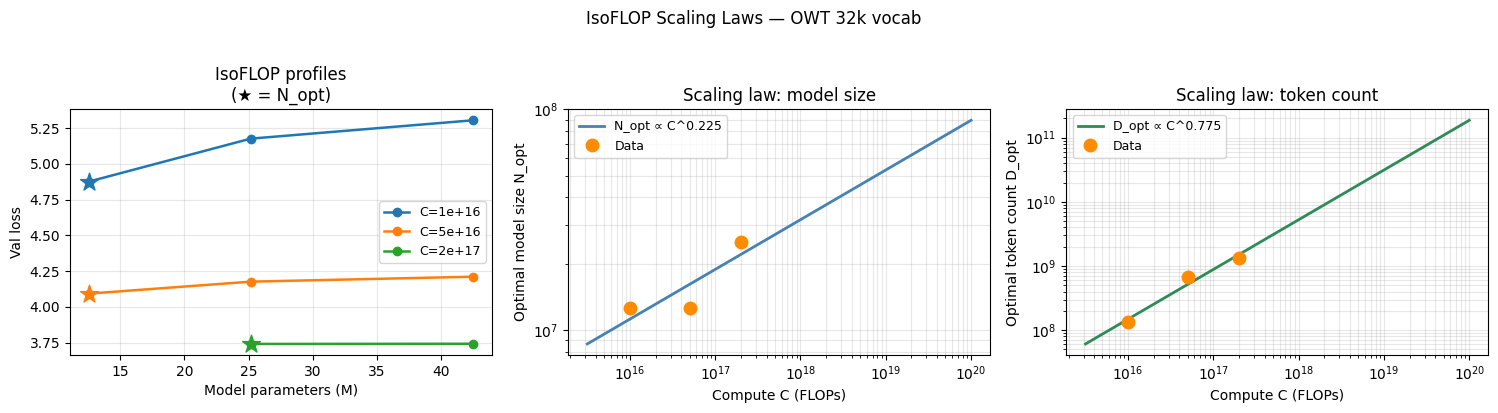


Saved: isoflop_scaling_laws.png


In [9]:
"""
Section 38 — IsoFLOP Scaling Law Fitting
Pull W&B results → find N_opt per budget → fit power laws → extrapolate.
"""
import os
import wandb
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Auth — paste your key from wandb.ai/authorize ────────────────────────────
WANDB_KEY = os.environ.get("WANDB_API_KEY", "")          # ← replace with actual key
os.environ['WANDB_API_KEY'] = WANDB_KEY
api     = wandb.Api(api_key=WANDB_KEY)
ENTITY  = "kpal1995"                 # ← hardcoded; avoids api.viewer() bug
PROJECT = "tokenized-universe-scaling"
print(f"Fetching runs from {ENTITY}/{PROJECT} ...")

# ── 1. Pull completed isoflop runs ───────────────────────────────────────────
ISOFLOP_BATCH   = 128
ISOFLOP_CONTEXT = 512

all_runs = api.runs(f'{ENTITY}/{PROJECT}')

records = []
for run in all_runs:
    if not run.name.startswith('isoflop_C'):
        continue
    if run.state != 'finished':
        print(f"  [skip — {run.state}] {run.name}")
        continue

    c       = run.config
    summary = run.summary

    val_loss = summary.get('val/loss')
    if val_loss is None:
        hist = run.history(keys=['val/loss'], pandas=False)
        rows = [r['val/loss'] for r in hist if 'val/loss' in r]
        val_loss = rows[-1] if rows else None
    if val_loss is None:
        print(f"  [skip — no val/loss] {run.name}")
        continue

    d_model    = c.get('d_model',        512)
    num_layers = c.get('num_layers',     4)
    batch_size = c.get('batch_size',     ISOFLOP_BATCH)
    ctx        = c.get('context_length', ISOFLOP_CONTEXT)
    steps      = c.get('num_steps',      0)

    N = 12 * num_layers * (d_model ** 2)
    D = batch_size * ctx * steps
    C = 6 * N * D

    records.append({'N': N, 'D': D, 'C': C, 'loss': val_loss, 'name': run.name})
    print(f"  {run.name:35s}  N={N/1e6:.1f}M  D={D/1e6:.0f}M  C={C:.2e}  loss={val_loss:.4f}")

print(f"\n{len(records)} runs loaded.")

# ── 2. Group by compute budget and find N_opt ─────────────────────────────────
TARGET_BUDGETS = [1e16, 5e16, 2e17]

def snap_budget(C, budgets, tol=0.4):
    """Assign run to nearest target budget within tol in log10 space."""
    for B in budgets:
        if abs(np.log10(C / B)) < tol:
            return B
    return None

by_budget = defaultdict(list)
for r in records:
    B = snap_budget(r['C'], TARGET_BUDGETS)
    if B is not None:
        by_budget[B].append(r)
    else:
        print(f"  [unmatched] {r['name']}  C={r['C']:.2e}")

C_pts, N_pts, D_pts = [], [], []
print('\nN_opt per compute budget:')
for B in sorted(by_budget):
    grp = by_budget[B]
    if len(grp) < 2:
        print(f"  C={B:.0e}: only {len(grp)} run — need ≥ 2 model sizes, skipping")
        continue
    best  = min(grp, key=lambda r: r['loss'])
    D_opt = B / (6 * best['N'])
    C_pts.append(B)
    N_pts.append(best['N'])
    D_pts.append(D_opt)
    print(f"  C={B:.0e}  →  N_opt={best['N']/1e6:.1f}M  "
          f"loss={best['loss']:.4f}  ({len(grp)} models, best={best['name']})")

assert len(C_pts) >= 2, (
    f"Only {len(C_pts)} usable budget(s). Need ≥ 2. "
    "Check that runs from at least 2 compute budgets are finished in W&B."
)

C_arr = np.array(C_pts)
N_arr = np.array(N_pts)
D_arr = np.array(D_pts)

# ── 3. Fit power laws in log space ───────────────────────────────────────────
def fit_power_law(C, Y, label):
    """Fit Y = A * C^a via linear regression in log space. Returns (A, a)."""
    a, logA = np.polyfit(np.log(C), np.log(Y), 1)
    A     = np.exp(logA)
    resid = np.log(Y) - (logA + a * np.log(C))
    rmse  = np.sqrt(np.mean(resid ** 2))
    print(f"  {label}: {A:.4g} × C^{a:.4f}   (log-RMSE = {rmse:.4f})")
    return A, a

print('\nPower law fits:')
A_N, a_N = fit_power_law(C_arr, N_arr, 'N_opt')
A_D, a_D = fit_power_law(C_arr, D_arr, 'D_opt')
print(f"\n  Chinchilla paper: exponents ≈ 0.50 for both")
print(f"  Your fit:         N_opt ∝ C^{a_N:.3f},  D_opt ∝ C^{a_D:.3f}")

# ── 4. Extrapolate ────────────────────────────────────────────────────────────
print('\nExtrapolations:')
for tgt_C in [1e18, 1e19, 1e20]:
    N_pred = A_N * tgt_C ** a_N
    D_pred = A_D * tgt_C ** a_D
    check  = 6 * N_pred * D_pred
    print(f"  C={tgt_C:.0e}:  N_opt={N_pred/1e9:.2f}B params,  "
          f"D_opt={D_pred/1e9:.1f}B tokens  (6ND={check:.1e})")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COLS  = ['#1f77b4', '#ff7f0e', '#2ca02c']
C_fit = np.logspace(np.log10(min(C_arr)) - 0.5, 20, 300)

# Panel 1 — IsoFLOP profiles
ax = axes[0]
for i, B in enumerate(sorted(by_budget)):
    grp  = sorted(by_budget[B], key=lambda r: r['N'])
    best = min(grp, key=lambda r: r['loss'])
    ax.plot([r['N']/1e6 for r in grp], [r['loss'] for r in grp],
            'o-', color=COLS[i % 3], linewidth=1.8, label=f'C={B:.0e}')
    ax.scatter([best['N']/1e6], [best['loss']],
               s=180, marker='*', color=COLS[i % 3], zorder=5)
ax.set_xlabel('Model parameters (M)')
ax.set_ylabel('Val loss')
ax.set_title('IsoFLOP profiles\n(★ = N_opt)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2 — N_opt vs C
ax = axes[1]
ax.loglog(C_fit, A_N * C_fit**a_N, '-', color='steelblue', linewidth=2,
          label=f'N_opt ∝ C^{a_N:.3f}')
ax.loglog(C_arr, N_arr, 'o', color='darkorange', ms=9, zorder=5, label='Data')
ax.set_xlabel('Compute C (FLOPs)')
ax.set_ylabel('Optimal model size N_opt')
ax.set_title('Scaling law: model size')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

# Panel 3 — D_opt vs C
ax = axes[2]
ax.loglog(C_fit, A_D * C_fit**a_D, '-', color='seagreen', linewidth=2,
          label=f'D_opt ∝ C^{a_D:.3f}')
ax.loglog(C_arr, D_arr, 'o', color='darkorange', ms=9, zorder=5, label='Data')
ax.set_xlabel('Compute C (FLOPs)')
ax.set_ylabel('Optimal token count D_opt')
ax.set_title('Scaling law: token count')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.suptitle("IsoFLOP Scaling Laws — OWT 32k vocab", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('isoflop_scaling_laws.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: isoflop_scaling_laws.png')